In [59]:
%pprint
import warnings
warnings.filterwarnings('ignore')

Pretty printing has been turned OFF


In [60]:
# Imported Libraries
import os, re
import numpy as np 
import pandas as pd
import seaborn as sns
from nltk import word_tokenize

import matplotlib.pyplot as plt
import matplotlib.image as img
from matplotlib.pyplot import MultipleLocator

import time
from datetime import datetime # datetime.datetime

from scipy import stats # 统计
from tqdm import tqdm   # 进度条
from IPython.display import display # 列表展示库 display(df)

import threading # 多线程
from concurrent.futures import ThreadPoolExecutor , as_completed # 线程池

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import GridSearchCV

# gensim
import gensim
import gensim.corpora as corpora
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, LdaModel

In [61]:
# Load Data
os.chdir("D:/Python_project/Infodemics/Media_Collection/Tfidf")  
path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/Cleaned Data_08_06/"

tw_pitt_text2day  = pd.read_csv(path+'Doc1_text2day.csv', index_col='Date')
tw_pitt_VN2day    = pd.read_csv(path+'Doc2_VN2day.csv', index_col='Date')
tw_pitt_N2day     = pd.read_csv(path+'Doc3_N2day.csv', index_col='Date')

original_text2day = pd.read_csv(path+'Doc4_original_text2day.csv', index_col='Date')
original_VN2day   = pd.read_csv(path+'Doc5_original_VN2day.csv', index_col='Date')
original_N2day    = pd.read_csv(path+'Doc6_original_N2day.csv', index_col='Date')

Docs = [ tw_pitt_text2day,  tw_pitt_VN2day,  tw_pitt_N2day, 
         original_text2day, original_VN2day, original_N2day ]

# Word Count

In [62]:
# Define word count function
# Define word count function
def count_words(wordslst):
    df = pd.DataFrame( {'Word': wordslst, 'Count':np.zeros(len(wordslst))} )
    wordcounts = df.groupby('Word').agg({'Count':np.size}).sort_values(by = 'Count', ascending = False)
    wordcounts['Prop%'] = (wordcounts.Count/len(wordslst))*100
    wordcounts = wordcounts.reset_index()
    
    # sort_values(by=‘ColumnName’, axis=0 , ascending = True , inplace = False, na_position = ‘last’ )
    # the column name of agg must be pre-determined
    # df = df.reset_index() can maintain the original index as a column and add a new index starting from 0

    return wordcounts
def checkWords(word, wordcounts):
    # wordcounts is the df defined from above using count_words( wordslst )     
    return wordcounts[ wordcounts['Words'] == word ]
def display_wordcounts(Type, rank, wordcounts, display=True):
    n = wordcounts.shape[0]
    
    if rank==-1:
        temp = wordcounts
        rank = wordcounts.shape[0]
    elif Type == 'top':
        temp = wordcounts.iloc[:rank,:]
    elif Type == 'bottom':
        temp = wordcounts.iloc[n-rank:,:]
        
    lst = [(temp.iloc[i,0],temp.iloc[i,1],temp.iloc[i,2]) for i in range(rank)]
    
    if display:     
        for i in range(rank):
            print("%-20s\t%-10d\t%.7f"%(lst[i][0],lst[i][1],lst[i][2]))     
    return lst

# add new stopwords
def add_stopwords(wordlst):
    path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/extra_stopwords_en.txt"   
    with open(path, 'a') as f:
        for word in wordlst:
            f.write('\n'+word)
    f.close()
    return
def update_stopwords():
    from nltk.corpus import stopwords as stpw
    stopwords = []
    path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/"
    with open(path+"stopwords_en.txt", "r") as f1:
        for stopword in f1.readlines():
            stopwords.append(stopword.strip('\n'))
        
    with open(path+"extra_stopwords_en.txt", "r") as f2:
        for stopword in f2.readlines():
            stopwords.append(stopword.strip('\n'))

    stopwords.extend(stpw.words('english'))
    stopwords = set(stopwords)
    return stopwords
def filter_words2(temp):
    # temp = tweet.lower()  
    # fist filter
    temp = [w for w in temp.split(' ') if not w in stopwords]
    temp = [w for w in temp if len(w)>2]
    
    temp = " ".join(word for word in temp)
    return temp

In [63]:
%%time
all_words  = [' '.join(list(Doc['Content'])).split() for Doc in Docs]
wordcounts = [count_words(x) for x in all_words]

CPU times: total: 6.97 s
Wall time: 7.09 s


In [83]:
# Word Count
DocNum   = 6 # 1,2,3,4,5,6
top_prop = 0

temp_counts = wordcounts[DocNum-1]
print(temp_counts[temp_counts['Prop%']>=top_prop]['Prop%'].sum())
print(temp_counts[temp_counts['Prop%']>=top_prop]['Count'].sum())
print()
top = display_wordcounts('top', -1, temp_counts[temp_counts['Prop%']>=top_prop])

100.0
1305098

mask                	55952     	4.2871876
case                	19236     	1.4739123
test                	18069     	1.3844937
work                	14711     	1.1271950
trump               	13624     	1.0439063
health              	12448     	0.9537981
death               	12383     	0.9488176
distancing          	11882     	0.9104297
vaccine             	11189     	0.8573303
stay                	10615     	0.8133489
news                	8852      	0.6782632
order               	7813      	0.5986524
distance            	7772      	0.5955108
business            	7503      	0.5748994
spread              	7093      	0.5434841
care                	6714      	0.5144441
school              	6712      	0.5142909
life                	6496      	0.4977404
family              	5760      	0.4413462
number              	5628      	0.4312320
worker              	5408      	0.4143750
die                 	5257      	0.4028050
response            	5160      	0.3953726
community          

peter               	168       	0.0128726
bob                 	168       	0.0128726
fake                	168       	0.0128726
conflict            	168       	0.0128726
miracle             	168       	0.0128726
constitution        	168       	0.0128726
pitch               	168       	0.0128726
professional        	167       	0.0127960
prof                	167       	0.0127960
madness             	167       	0.0127960
noon                	167       	0.0127960
hotspot             	167       	0.0127960
didnt               	167       	0.0127960
cope                	167       	0.0127960
warns               	167       	0.0127960
century             	167       	0.0127960
random              	166       	0.0127194
abuse               	166       	0.0127194
rona                	166       	0.0127194
bathroom            	166       	0.0127194
collect             	166       	0.0127194
perfect             	165       	0.0126427
partnership         	165       	0.0126427
nonsense            	165       	0.

In [74]:
# Generate wordcloud
# Import the wordcloud library
# import matplotlib.pyplot as plt

from wordcloud import WordCloud
from PIL import Image

def drawWordCloud( wordcounts , topNumber , figuresize , filename ): 
    word_frequency = {x[0]:x[1] for x in wordcounts.head(topNumber).values} # 返回二维列表，外层元素为Observation 
    
    if len(filename) == 0 :
        wordcloud = WordCloud(scale=10, background_color="white", 
                              max_words=topNumber, contour_width=3, contour_color='steelblue')
    # scale - pic quality
    else :
        shape = np.array( Image.open(os.path.join(os.getcwd(),filename)) ) # current working path os.getcwd()
        wordcloud = WordCloud(scale=10, background_color="white", 
                              mask=shape, max_words=topNumber)
     
    # Generate a word cloud
    wordcloud.fit_words(word_frequency)
    
    # Visualize the word cloud
    fig = plt.figure( figsize = figuresize ) 
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()
    
    return fig

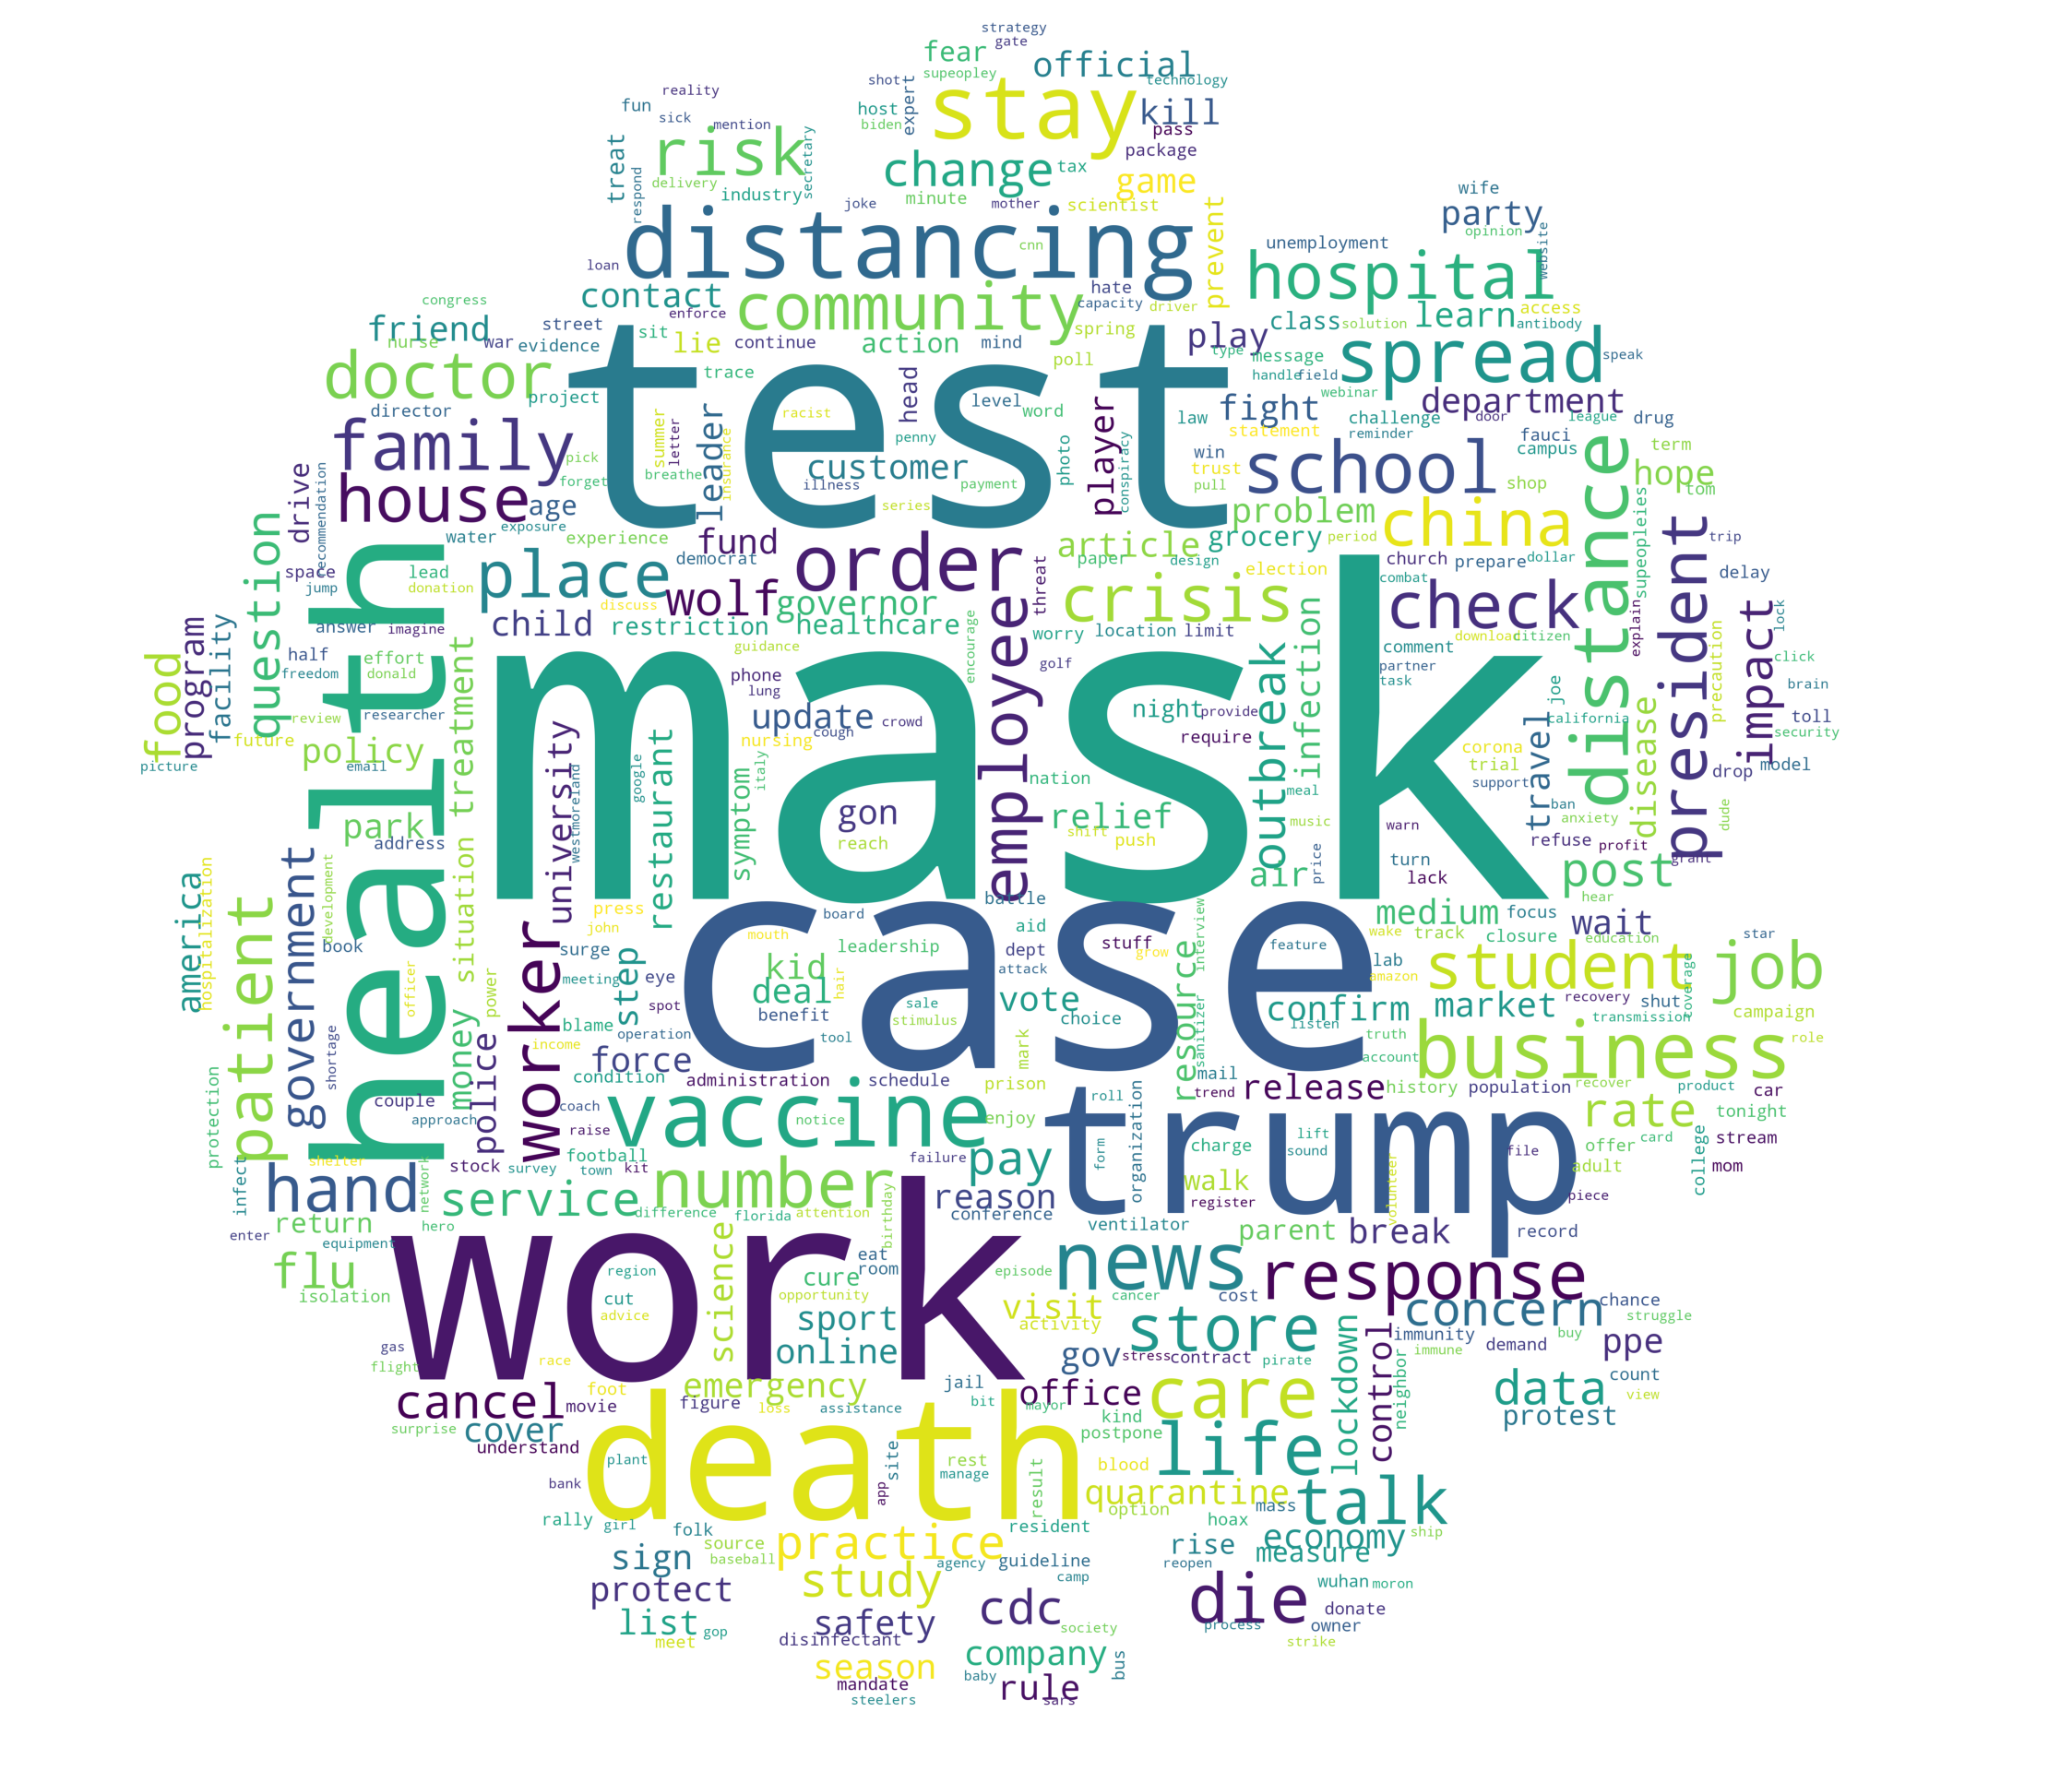

In [80]:
fig = drawWordCloud( wordcounts[5] , 500 , (40,40) , 'covid.jpg' )
if False :
        fig.savefig('./plot/Doc6_original_N2day.jpg', transparent = False, bbox_inches = 'tight')

# TF-IDF Analysis

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
# Load Data
os.chdir("D:/Python_project/Infodemics/Media_Collection/Tfidf")  
path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/Cleaned Data_08_06/"

tw_pitt_text2day  = pd.read_csv(path+'Doc1_text2day.csv', index_col='Date')
tw_pitt_VN2day    = pd.read_csv(path+'Doc2_VN2day.csv', index_col='Date')
tw_pitt_N2day     = pd.read_csv(path+'Doc3_N2day.csv', index_col='Date')

original_text2day = pd.read_csv(path+'Doc4_original_text2day.csv', index_col='Date')
original_VN2day   = pd.read_csv(path+'Doc5_original_VN2day.csv', index_col='Date')
original_N2day    = pd.read_csv(path+'Doc6_original_N2day.csv', index_col='Date')

Docs = [ tw_pitt_text2day,  tw_pitt_VN2day,  tw_pitt_N2day, 
         original_text2day, original_VN2day, original_N2day ]

Days = tw_pitt_text2day.index

## Daily TF-IDF

### Functions

In [78]:
# Notes

# from sklearn.feature_extraction.text import TfidfVectorizer

# step 1 define the document list
corpus = ['This is the first document.',
          'This document is the second document.',
          'And this is the third one.',
          'Is this the first document?']

# step 2 construct the model object
vectorizer = TfidfVectorizer() 

# step 3 fit the model with the document sequence as the form of "corpus" 
X = vectorizer.fit_transform(corpus) 

# step 4 get terms appeared in the whole documnet set in the form of an array
terms = vectorizer.get_feature_names_out() 

# What dose the vectorizer.fit_transform(document_list) return ?
''' A sparse matrix denoting

                 term 0      term 1        term 2     ...
document 0    tf-idf(0,0)  tf-idf(0,1)   tf-idf(0,2)    
document 1    tf-idf(1,0)  tf-idf(1,1)   tf-idf(1,2) 
document 2    tf-idf(2,0)  tf-idf(2,1)   tf-idf(2,2) 
   .
   .
   .

'''

# What is a sparse martix ?
'''
A sparse matrix in python is a matrix whose elements are mostly zero and thus are eliminated by python, 
one can use Matrix[a,b] to access its elements. A matrix that is mnot sparse is a dense matrix

dense = <sparse>.todense() : transform a sparse matrix to dense form
2Dlist = <dense>.tolist()  : transform a dense matrix to 2Dlist form
print(sparse) : can print the sparse matrix

'''

# whod dose the sklearn calculated the tf-idf ?
# https://www.analyticsvidhya.com/blog/2021/11/how-sklearns-tfidfvectorizer-calculates-tf-idf-values/
'''
Let : D be the total document list as 'corpus'
      d be one specific document in D as 'This is the first document.'
      t be one specific term that has appeared in D as 'This'
      n = Total number of documents available
      t = term for which idf value has to be calculated
      df(t) = Number of documents in which the term t appears
 
tf(t,d) = Number of times a term ‘t’ appears in a document d

idf(t,D) = ln[ (1+n) / ( 1 + df(t) ) ] + 1    (default i.e smooth_idf = True)
idf(t,D) = ln[ n / df(t) ] + 1                (when smooth_idf = False)

tf-idf(t,d,D) = tf(t,d)*idf(t,D)

sklearn than normalize the tf-idfs for each line in the sparse matrix:

                                 term 0      term 1        term 2     ...
                document 0    tf-idf(0,0)  tf-idf(0,1)   tf-idf(0,2)    
                document 1    tf-idf(1,0)  tf-idf(1,1)   tf-idf(1,2) 
                document 2    tf-idf(2,0)  tf-idf(2,1)   tf-idf(2,2) 
                   .
                   .
                   .
 
''';

In [302]:
# Define a function, receiving a dataframe in the form as cbs_date_to_word and returns a dataframe recording the tf-idfs 
# of each appearing terms as a time sequence
'''   
                                    term 0      term 1        term 2     ...
                        day 0    tf-idf(0,0)  tf-idf(0,1)   tf-idf(0,2)  
                        day 1    tf-idf(1,0)  tf-idf(1,1)   tf-idf(1,2)  
                        day 2    tf-idf(2,0)  tf-idf(2,1)   tf-idf(2,2)  
                           .
                           .
                           .
'''
def track_tfidf(df, cal_window=7, min_df=0, max_df=1):
    # from tqdm import tqdm  
    # from sklearn.feature_extraction.text import TfidfVectorizer
    days = df.index
    statistics_tfidf = pd.DataFrame( index = days )

    for day in tqdm(days):
        
        n = list(days).index(day)
        
        if  cal_window == -1:
            articles = list(df.iloc[:n+1,0]) 
        else:
            if n < cal_window - 1:
                articles = list(df.iloc[:n+1,0])
            else:
                articles = list(df.iloc[n-cal_window+1:n+1,0])
                
        vectorizer = TfidfVectorizer(min_df=min_df, max_df=max_df)
        X = vectorizer.fit_transform(articles)
        finalday_tfidf = X.todense().tolist()[-1]
        terms = list( vectorizer.get_feature_names_out() )
        
        for term in terms :
            statistics_tfidf.loc[day,term] = finalday_tfidf[terms.index(term)]   
            
        daily_tfidf = pd.DataFrame(statistics_tfidf.mean(axis=1),columns=['TF-IDF'])
            
    return statistics_tfidf, daily_tfidf
def plot_tfidf(daily_tfidf, figsize=(16, 10), 
                            title='Local Media Daily Average Standardized TF-IDF Trending',
                            title_size=18, tick_size=15):
    
    fig = plt.figure( figsize = (16, 10) ) 
    plt.plot (daily_tfidf, linewidth=2, linestyle='-', color=(0, 95/255, 115/255)); 

    try:
        m = daily_tfidf.iloc[:,0].min()
        M = daily_tfidf.iloc[:,0].max()
    except:
        m = daily_tfidf.min()
        M = daily_tfidf.max()
    step = (M-m)/20
    ytk = np.append(np.arange(m,M,step), M)

    plt.title(title, fontproperties='Times New Roman', fontsize=title_size, fontweight="bold");
    plt.xticks(daily_tfidf.index[0::5], fontproperties='Times New Roman', fontsize=tick_size, rotation=90, fontweight="bold");
    plt.yticks(ytk, fontproperties='Times New Roman', size=tick_size, fontweight="bold");
    plt.grid();
    
    return fig
def plot_combined_tfidf(daily_tfidfs_lst, figsize=(16, 10), 
               title='Local Media Daily Average Standardized TF-IDF Trending',
               title_size=18, tick_size=15):
    
    ax = daily_tfidfs_lst.plot(linewidth=2, figsize=figsize, xlabel=''); 

    # xticks 
    xtk = daily_tfidfs_lst.index[0::5]
    xtkpos = range(0,len(daily_tfidfs_lst.index),5)
    plt.xticks(xtkpos, xtk,fontproperties='Times New Roman', 
               fontsize=tick_size, rotation=90, fontweight="bold");
    # yticks
    m = daily_tfidfs_lst.min().min()
    M = daily_tfidfs_lst.max().max()
    step = (M-m)/20
    ytk = np.append(np.arange(m,M,step), M)
    plt.yticks(ytk, fontproperties='Times New Roman', 
               size=tick_size, fontweight="bold"); 

    # title, legend & grid    
    plt.title(title, fontproperties='Times New Roman', 
              fontsize=title_size, fontweight="bold");
    plt.legend(prop={'size':tick_size, 'family':'Times New Roman', 'weight':'bold'})
    plt.grid();
    
    fig = ax.get_figure()
    
    return fig

# detect missing days
def detect_Missing_days(index):
    dates = pd.to_datetime(index)
    missing_day = []
    for i in range(1,len(dates)):
        delta = (dates[i]-dates[i-1]).days
        if  delta != 1:    
            for j in range(1,delta):
                tempday = dates[i-1] + pd.Timedelta(days=j)
                daystr = tempday.strftime('%Y/%m/%d')
                missing_day.append(daystr)         
    return  missing_day    
def day_before(missing_day):
    dates = pd.to_datetime(missing_day)
    day_before = [ (date - pd.Timedelta(days=1)).strftime('%Y/%m/%d') for date in dates]
    return  day_before
def day_after(missing_day):
    dates = pd.to_datetime(missing_day)
    day_after = [ (date + pd.Timedelta(days=1)).strftime('%Y/%m/%d') for date in dates]
    return  day_after
def fill_Missing_days1(ser):
    # ser here is in df form
    dates = ser.index
    missing_day = detect_Missing_days(dates)
    if len(missing_day)==0:
           return ser
    before = day_before(missing_day)
    after  = day_after(missing_day)
    for day in missing_day:
        i = missing_day.index(day)
        try:
            ser[day] = ser[[before[i],after[i]]].mean()
        except:
            print('Can not apply fill_Missing_days1')
            return
    ser.sort_index(inplace=True)
    return ser

# forward value smooth
def forward_mean_smooth(lst, smooth_window=7):
    result = []  
    if smooth_window == -1:
        for i in range(len(lst)):
            temp = lst[:i+1]
            result.append(sum(temp)/(i+1))
    else:     
        for i in range(len(lst)):
            if i<smooth_window-1:
                temp = lst[:i+1]
                result.append(sum(temp)/(i+1))
            else:
                temp = lst[i-smooth_window+1:i+1]
                result.append(sum(temp)/(smooth_window))
    return result
def forward_exp_smooth(lst, smooth_window=-1, Lambda=0.2):
    result = []  
    lst = np.array(lst)
    if smooth_window == -1:
        for i in range(len(lst)):
            weight = (Lambda*(1-Lambda)**np.arange(i+1))[::-1]
            temp = lst[:i+1]*weight
            result.append(temp.sum())
    else: 
        weight = (Lambda*(1-Lambda)**np.arange(smooth_window))[::-1]
        for i in range(len(lst)):
            if i<smooth_window:
                temp = weight[-(i+1):]*lst[:i+1]
                result.append(temp.sum())
            else:
                temp = weight*lst[i-smooth_window+1:i+1]
                result.append(temp.sum())
    return result
def forward_mix_smooth(lst, smooth_window=-1, Lambda=0.2):
    result = []  
    lst = np.array(lst)
    if smooth_window == -1:
        for i in range(len(lst)):
            weight = (Lambda*(1-Lambda)**np.arange(i+1))[::-1]
            if weight.sum()>=0.7:
                temp = lst[:i+1]*weight
                result.append(temp.sum())
            else:
                temp = lst[:i+1]
                result.append(sum(temp)/(i+1))
    else: 
        weight = (Lambda*(1-Lambda)**np.arange(smooth_window))[::-1]
        if weight.sum()<0.85:
            raise ValueError('weight.sum()<0.85')
        for i in range(len(lst)):
            if i<smooth_window:
                wt = weight[-(i+1):]
                if wt.sum()>=0.7:
                    temp = lst[:i+1]*wt
                    result.append(temp.sum())
                else:
                    temp = lst[:i+1]
                    result.append(sum(temp)/(i+1))
            else:
                temp = weight*lst[i-smooth_window+1:i+1]
                result.append(temp.sum())
    return result

### Calculation

In [141]:
# Word Count
DocNum   = 6 # 1,2,3,4,5,6
top_prop = 0

temp_counts = wordcounts[DocNum-1]
print(temp_counts[temp_counts['Prop%']>=top_prop]['Prop%'].sum())
print(temp_counts[temp_counts['Prop%']>=top_prop]['Count'].sum())
print()
top = display_wordcounts('top', -1, temp_counts[temp_counts['Prop%']>=top_prop])

100.0
1305098

mask                	55952     	4.2871876
case                	19236     	1.4739123
test                	18069     	1.3844937
work                	14711     	1.1271950
trump               	13624     	1.0439063
health              	12448     	0.9537981
death               	12383     	0.9488176
distancing          	11882     	0.9104297
vaccine             	11189     	0.8573303
stay                	10615     	0.8133489
news                	8852      	0.6782632
order               	7813      	0.5986524
distance            	7772      	0.5955108
business            	7503      	0.5748994
spread              	7093      	0.5434841
care                	6714      	0.5144441
school              	6712      	0.5142909
life                	6496      	0.4977404
family              	5760      	0.4413462
number              	5628      	0.4312320
worker              	5408      	0.4143750
die                 	5257      	0.4028050
response            	5160      	0.3953726
community          

land                	242       	0.0185427
celebrity           	242       	0.0185427
theme               	241       	0.0184660
favor               	240       	0.0183894
cbsn                	239       	0.0183128
politician          	239       	0.0183128
attend              	239       	0.0183128
oxygen              	239       	0.0183128
balance             	239       	0.0183128
din                 	238       	0.0182362
japan               	238       	0.0182362
key                 	238       	0.0182362
downplay            	238       	0.0182362
gold                	238       	0.0182362
neck                	238       	0.0182362
assist              	238       	0.0182362
hockey              	237       	0.0181596
bernie              	237       	0.0181596
sew                 	237       	0.0181596
develop             	237       	0.0181596
institution         	237       	0.0181596
homeless            	236       	0.0180829
positivity          	236       	0.0180829
studio              	236       	0.

In [158]:
%%time
# 7 Days
tfidfs_c7 = []
daily_tfidfs_c7 = pd.DataFrame(columns=['all_full','all_VN','all_N',
                                        'ori_full','ori_VN','ori_N'],
                               index=Days)
min_dfs = [0,0.0014941,0.0016394,0.0053368,0.0069746,0.0076622]

for i in range(6):
    Doc = Docs[i]
    print('Start Doc_%d'%(i+1))
    tfidf, daily_tfidf = track_tfidf(Doc, cal_window=7, min_df=min_dfs[i])
    tfidfs_c7.append(tfidf)
    daily_tfidfs_c7.iloc[:,i] = daily_tfidf
    print('Finish Doc_%d'%(i+1))
    print('')

Start Doc_1


100%|████████████████████████████████████████████████████████████████████████████████| 245/245 [00:35<00:00,  6.82it/s]


Finish Doc_1

Start Doc_2


100%|████████████████████████████████████████████████████████████████████████████████| 245/245 [00:27<00:00,  8.95it/s]


Finish Doc_2

Start Doc_3


...

Finish Doc_4

Start Doc_5


100%|████████████████████████████████████████████████████████████████████████████████| 245/245 [00:11<00:00, 21.83it/s]


Finish Doc_5

Start Doc_6


100%|████████████████████████████████████████████████████████████████████████████████| 245/245 [00:10<00:00, 23.05it/s]

Finish Doc_6

CPU times: total: 2min 3s
Wall time: 2min 3s


In [315]:
# save data
daily_tfidfs_c7.to_csv('tw_pitt_daily_tfidf_raw_c7.csv', index=True)  

nameset = ['all_full','all_VN','all_N', 'ori_full','ori_VN','ori_N']
for i in range(6):
    df = tfidfs_c7[i]
    namstr = 'Doc%d_'%(i+1)+'tw_pitt_tfidf_withna_'+nameset[i]+'_c7.csv'
    df.to_csv(namstr, index=True)  

In [311]:
# smooth
daily_tfidfs_mean_c7 = daily_tfidfs_c7.apply(lambda x: forward_mean_smooth(list(x), smooth_window=7), axis=0)
daily_tfidfs_exp_c7  = daily_tfidfs_c7.apply(lambda x: forward_exp_smooth(list(x), smooth_window=-1, Lambda=0.2), axis=0)
daily_tfidfs_mix_c7  = daily_tfidfs_c7.apply(lambda x: forward_mix_smooth(list(x), smooth_window=-1, Lambda=0.2), axis=0)

daily_tfidfs_mean_c7.to_csv('tw_pitt_daily_tfidf_mean_c7_s7.csv', index=True) 
daily_tfidfs_exp_c7.to_csv('tw_pitt_daily_tfidf_exp_c7_s-1.csv', index=True) 
daily_tfidfs_mix_c7.to_csv('tw_pitt_daily_tfidf_mix_c7_s-1.csv', index=True) 

### Visualization

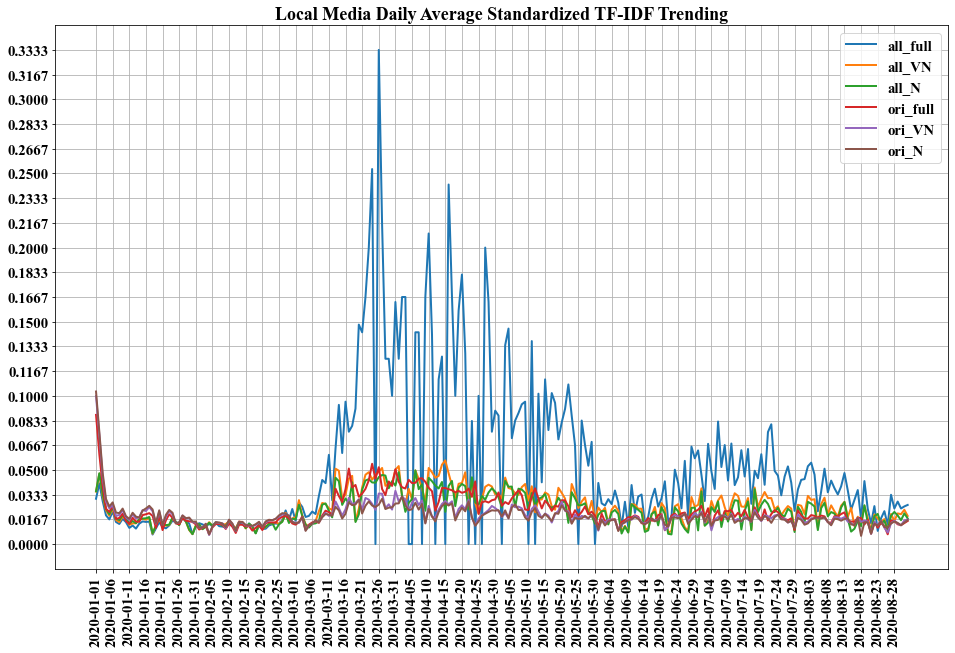

In [289]:
fig = plot_combined_tfidf(daily_tfidfs_c7)

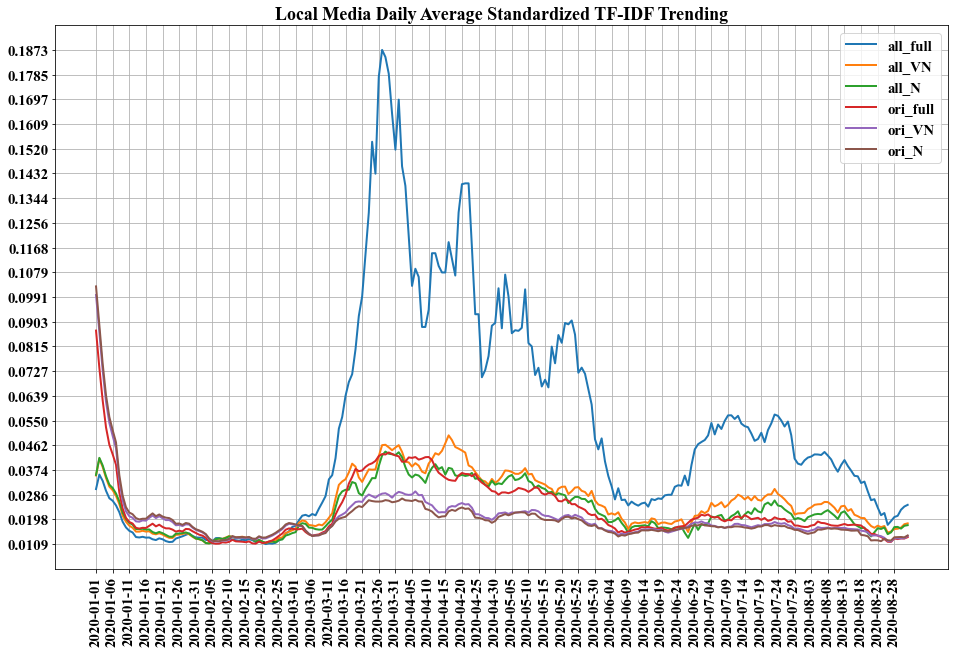

In [306]:
fig = plot_combined_tfidf(daily_tfidfs_mean_c7)
if False:
    fig.savefig('./plot/daily_tfidfs_mean_c7_s7.jpg', bbox_inches = 'tight')

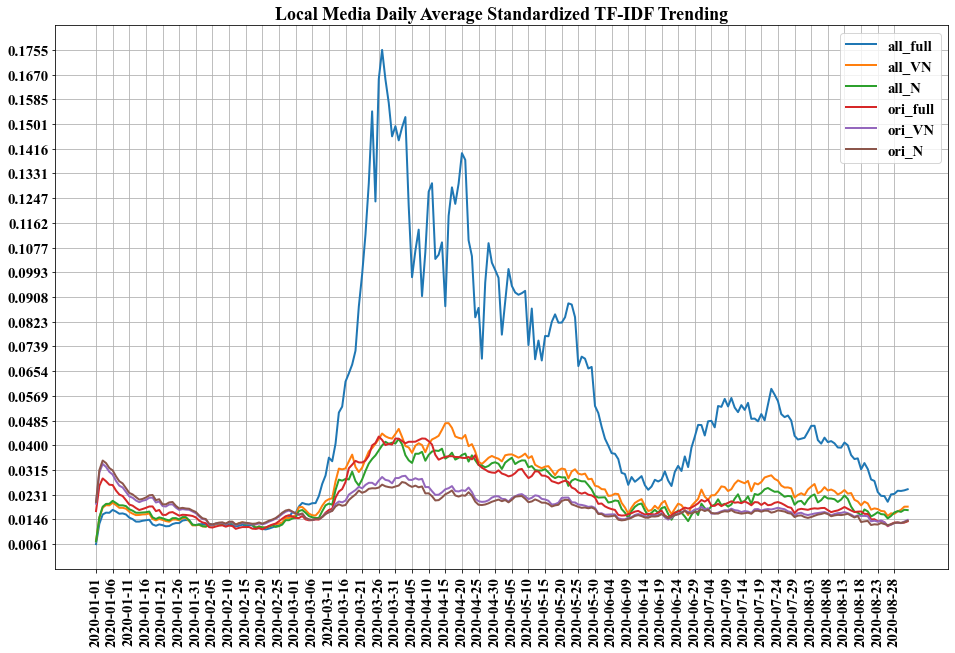

In [307]:
fig = plot_combined_tfidf(daily_tfidfs_exp_c7)
if True:
    fig.savefig('./plot/daily_tfidfs_exp_c7_s-1.jpg', bbox_inches = 'tight')

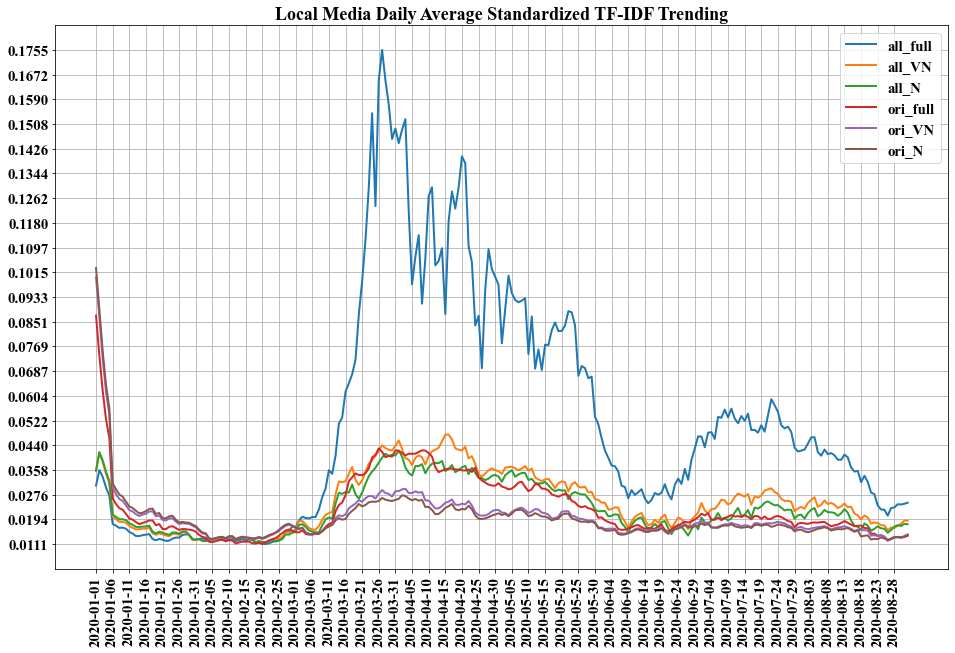

In [308]:
fig = plot_combined_tfidf(daily_tfidfs_mix_c7)
if True:
    fig.savefig('./plot/daily_tfidfs_mix_c7_s-1.jpg', bbox_inches = 'tight')

## More Visualization

In [318]:
# Load data
cal_window = 7

tfidfs = []
nameset = ['all_full','all_VN','all_N', 'ori_full','ori_VN','ori_N']
os.chdir("D:/Python_project/Infodemics/Media_Collection/Tfidf")  
for i in range(6):
    namstr = 'Doc%d_'%(i+1)+'tw_pitt_tfidf_withna_'+nameset[i]+'_c%d.csv'%cal_window
    df = pd.read_csv(namstr,index_col='Date')
    tfidfs.append(df)

### Functions 

In [23]:
# Plot the tf-idf trendings for top 100 words with a maximum numbers of non-zero values
def trendingheatmap(df,topNumber):
    top_index = df.mean().sort_values(ascending = False)[:topNumber].index
    top_statistics = df.loc[:,top_index]
    maxVal = top_statistics.max().max()
    minVal = top_statistics.min().min()
    fig = plt.figure(figsize = (10,10))
    sns.heatmap(top_statistics.T, center = (maxVal+minVal)/2 , cmap = "rocket_r")
    return fig


# Average tf-idfs for each term
def plot_wordsAverage_tfidf( df, topNumber = 50 ):
    average = df.mean().sort_values( ascending = False )
    
    # Parameters
    labelsize = 20
    titlesize = 25
    ticksize = 20
    tickrotation = 90
    
    fig = plt.figure( figsize = (20, 10) ) 
    ser = average[:topNumber]

    x = np.arange(len(ser))
    bar_width = 0.5

    # Plot bar chart
    plt.rc('axes', axisbelow=True) # grid behind plot
    plt.grid(linestyle = '-', linewidth = 1)
    plt.bar(x , ser , label = 'Standardized Average TF-IDFs' , 
            width = bar_width , color = (0, 53/255, 102/255))


    # Add title & ticks
    plt.title('Word-wise Average TF-IDFs: Top %d'%topNumber, fontproperties = 'Times New Roman', 
              fontsize = titlesize, fontweight="bold");
    plt.xticks(x , ser.index, fontproperties = 'Times New Roman', fontsize = ticksize, 
               rotation = tickrotation, fontweight="bold");
    plt.yticks(fontproperties = 'Times New Roman', size = ticksize, fontweight="bold");

    return fig

### Display

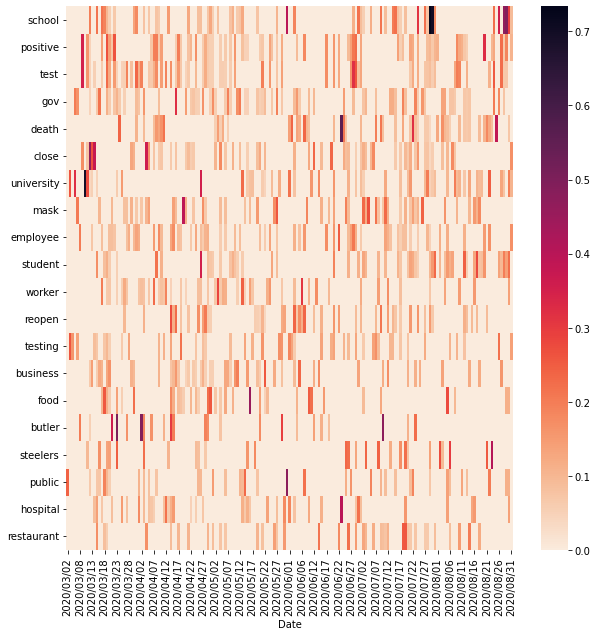

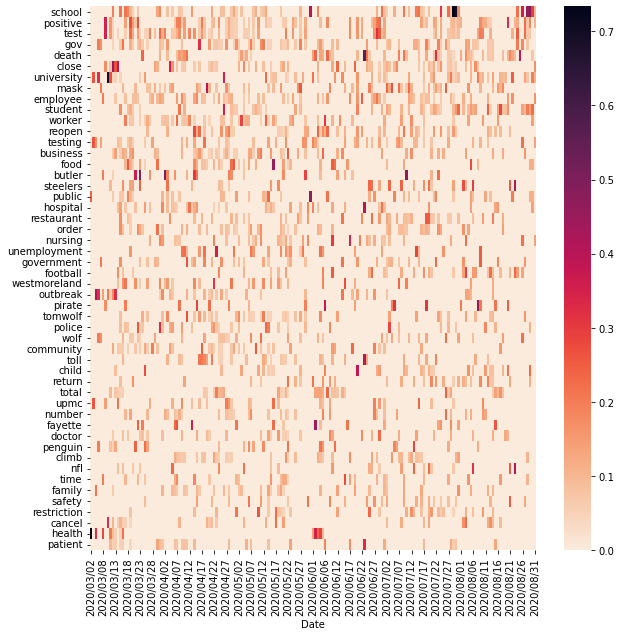

In [144]:
fig1 = trendingheatmap(cbs_tfidf4,20)
fig2 = trendingheatmap(cbs_tfidf4,50)

if False :
        fig1.savefig(r'./Plot/CBS_KDKA/cbs_tfidf_heapmap_top20.jpg', bbox_inches = 'tight')
        fig2.savefig(r'./Plot/CBS_KDKA/cbs_tfidf_heapmap_top50.jpg', bbox_inches = 'tight')

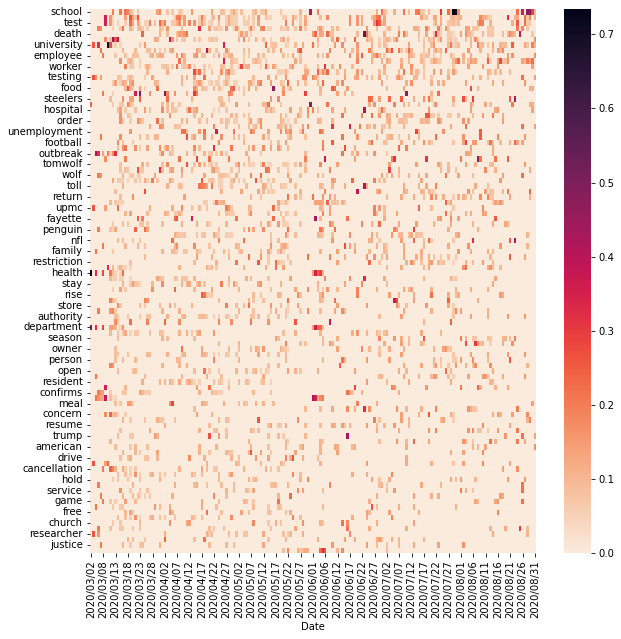

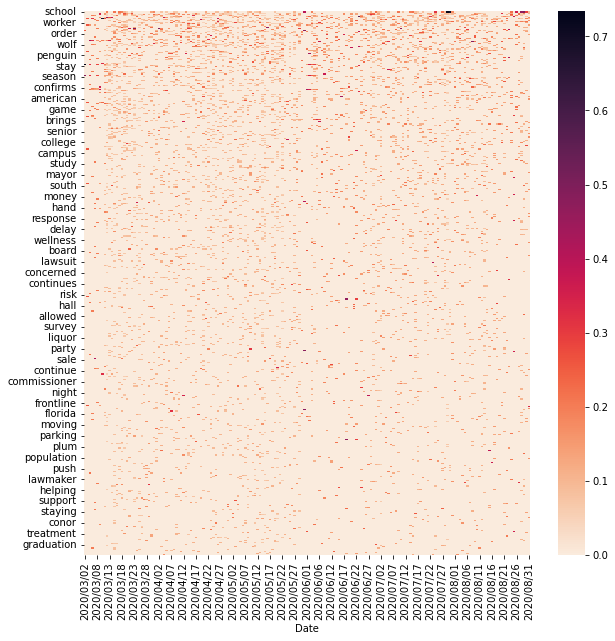

In [145]:
fig3 = trendingheatmap(cbs_tfidf4,100)
fig4 = trendingheatmap(cbs_tfidf4,500)

if False :
        fig3.savefig(r'./Plot/CBS_KDKA/cbs_tfidf_heapmap_top100.jpg', bbox_inches = 'tight')
        fig4.savefig(r'./Plot/CBS_KDKA/cbs_tfidf_heapmap_top500.jpg', bbox_inches = 'tight')

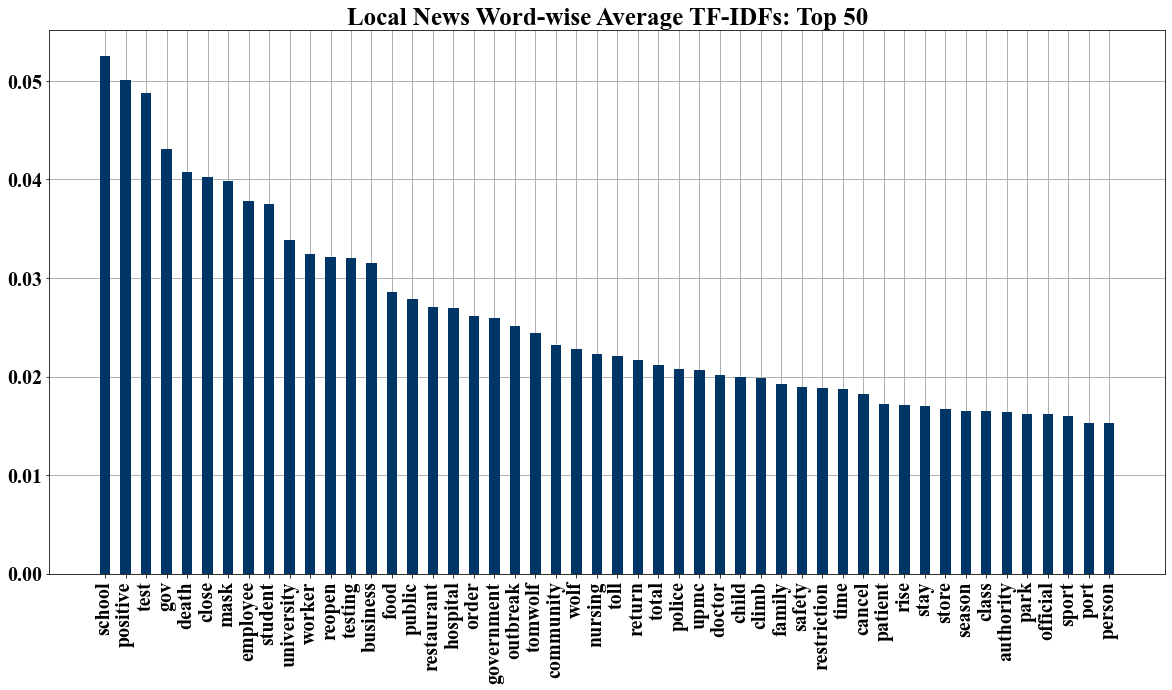

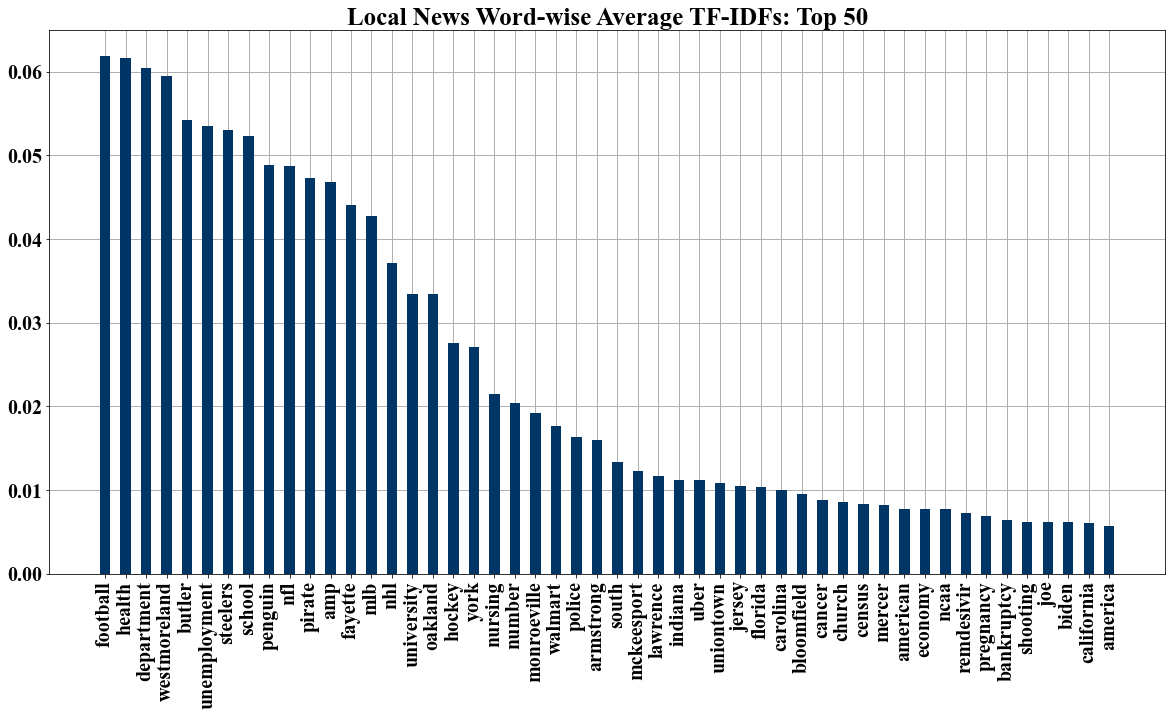

In [147]:
# weekly staged
fig1 = plot_wordsAverage_tfidf( cbs_tfidf1 )
fig2 = plot_wordsAverage_tfidf( cbs_tfidf2 )

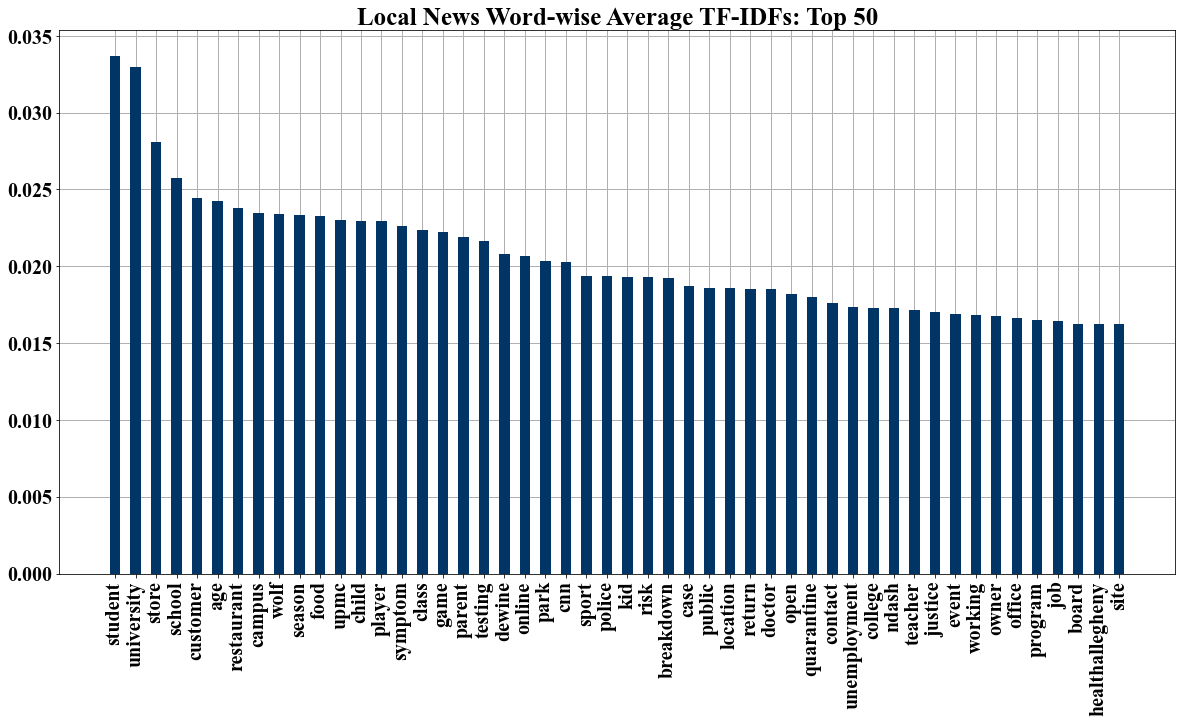

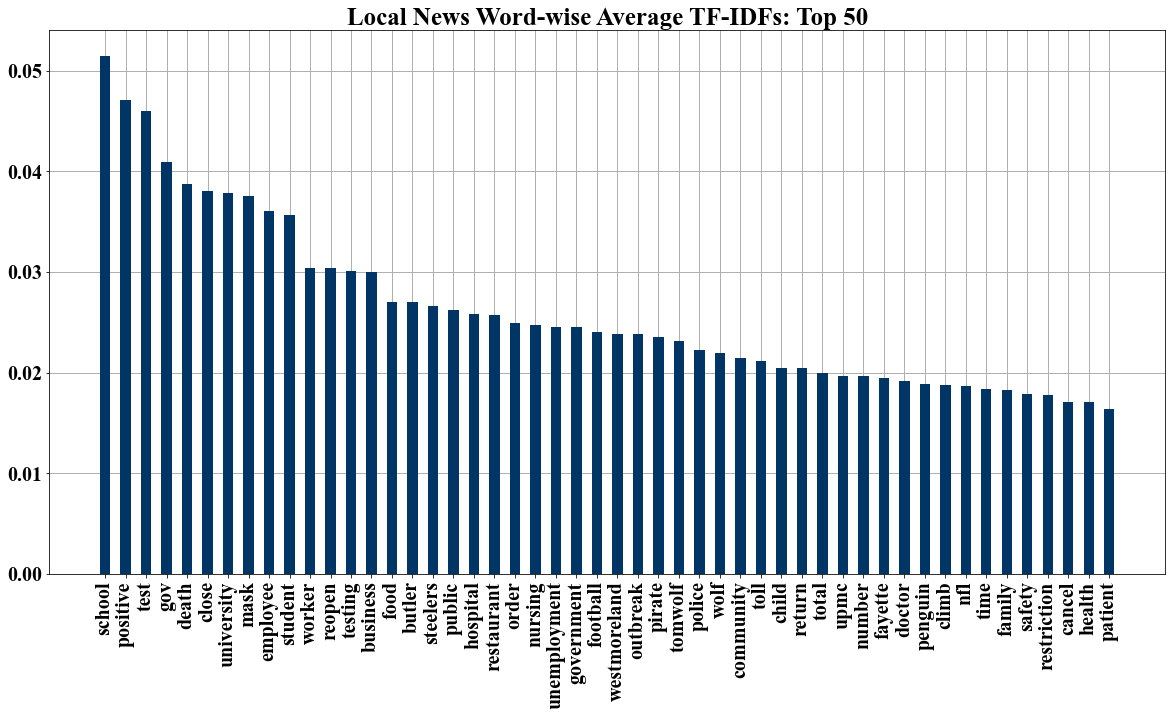

In [148]:
# weekly staged
fig3 = plot_wordsAverage_tfidf( cbs_tfidf3 )
fig4 = plot_wordsAverage_tfidf( cbs_tfidf4 )

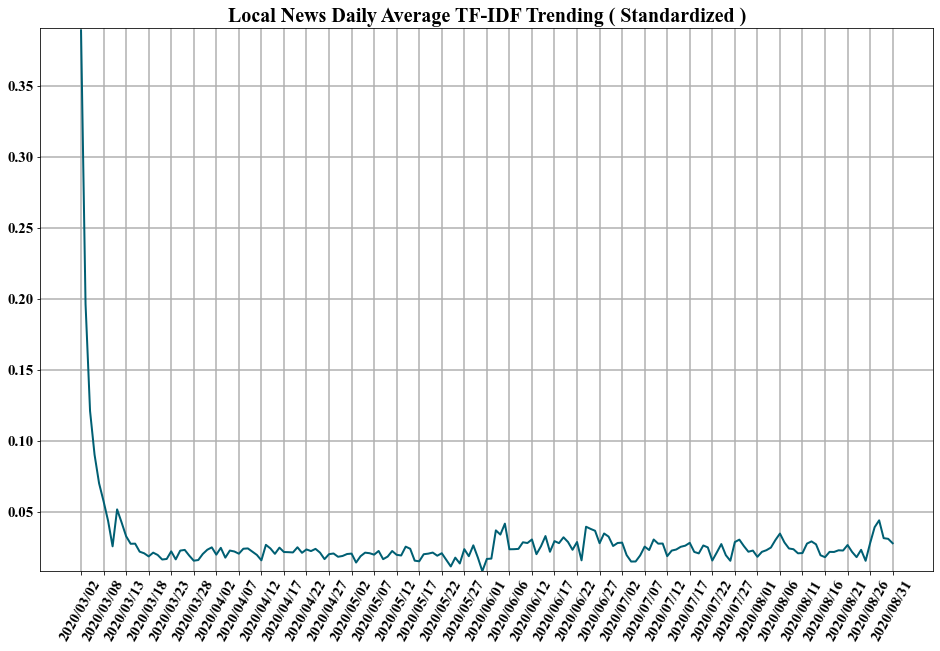

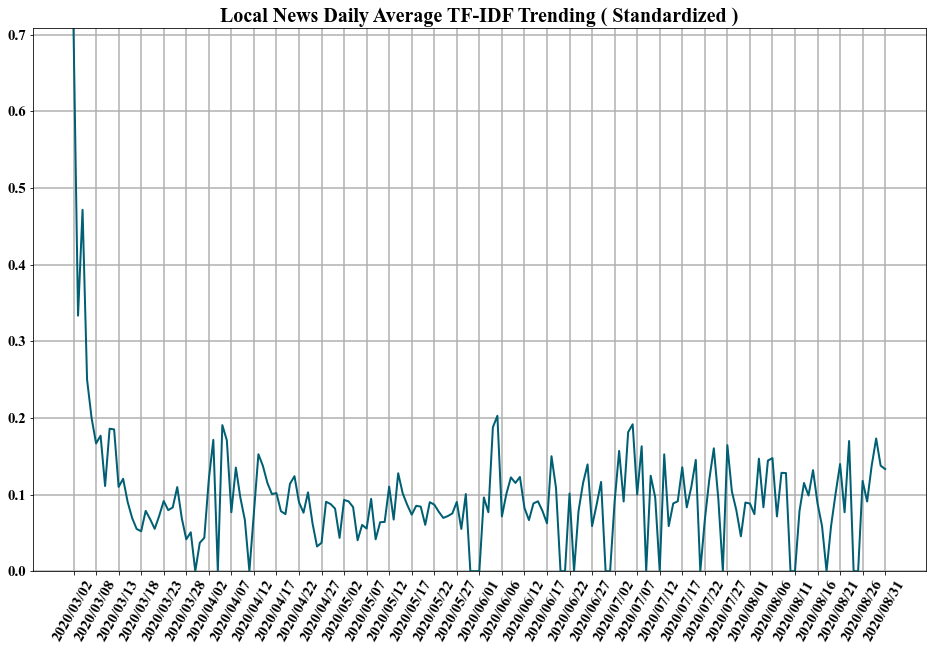

In [152]:
# weekly staged
Fig1 = plot_dailyAverage_tfidf( cbs_tfidf_withna1 )
Fig2 = plot_dailyAverage_tfidf( cbs_tfidf_withna2 )

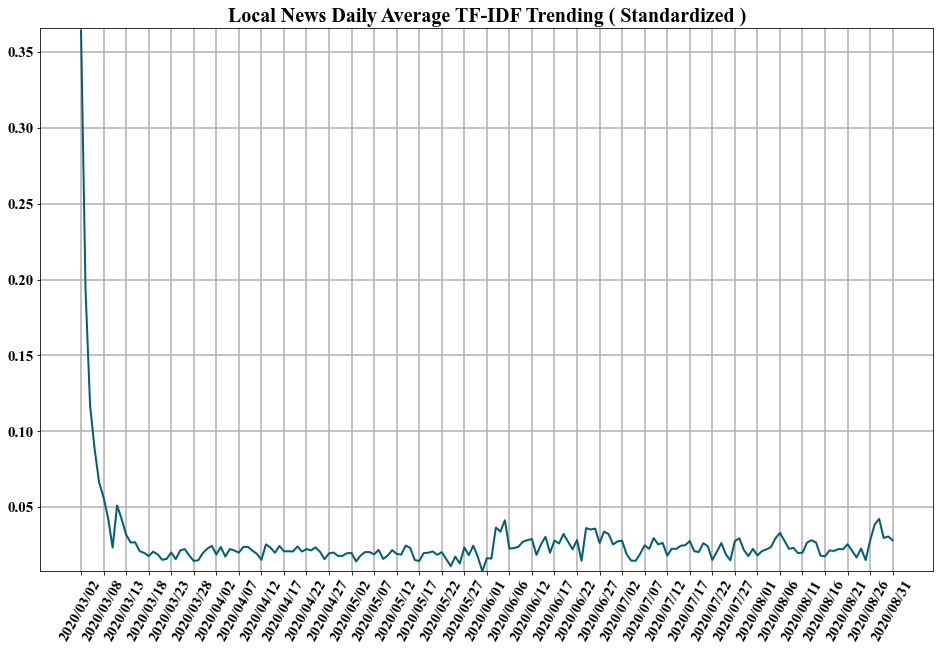

In [26]:
# weekly staged
Fig3 = plot_dailyAverage_tfidf( cbs_tfidf_withna3 )
Fig4 = plot_dailyAverage_tfidf( cbs_tfidf_withna4 )

In [291]:
if False :
    Fig1.savefig(r'./Plot/CBS_KDKA/cbs_DailyAverage_tfidf_1.jpg', bbox_inches = 'tight')
    Fig2.savefig(r'./Plot/CBS_KDKA/cbs_DailyAverage_tfidf_2.jpg', bbox_inches = 'tight')
    Fig3.savefig(r'./Plot/CBS_KDKA/cbs_DailyAverage_tfidf_3.jpg', bbox_inches = 'tight')
    Fig4.savefig(r'./Plot/CBS_KDKA/cbs_DailyAverage_tfidf_4.jpg', bbox_inches = 'tight')

# Topic Analysis LDA

In [27]:
# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import GridSearchCV

# gensim
import gensim
import gensim.corpora as corpora
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, LdaModel

'''
CountVectorizer : 

The use of CountVectorizer is similar as TfidfVectorizer, instead, it returns
a sparse representation of the word counts rather than tf-idfs

similarly, use : 

vectorizer = CountVectorizer() to construct the model

X = vectorizer.fit_transform(documnet_list) to fit the model

vectorizer.get_feature_names_out() to get the feature



                                  term 0         term 1           term 2     ...
                document 0    wordcount(0,0)  wordcount(0,1)   wordcount(0,2)    
       X =      document 1    wordcount(1,0)  wordcount(1,1)   wordcount(1,2) 
                document 2    wordcount(2,0)  wordcount(2,1)   wordcount(2,2) 
                   .
                   .
                   .
''' ;

In [28]:
# Read data
cbs       = pd.read_csv('./Data/CBS_KDKA/cbs_clean.csv', encoding = "utf_8_sig")
cbs_list1 = pd.read_csv('./Data/CBS_KDKA/cbs_title.csv', encoding = "utf_8_sig")
cbs_list2 = pd.read_csv('./Data/CBS_KDKA/cbs_keywords.csv', encoding = "utf_8_sig")
cbs_list3 = pd.read_csv('./Data/CBS_KDKA/cbs_content.csv', encoding = "utf_8_sig")
cbs_list4 = pd.read_csv('./Data/CBS_KDKA/cbs_selectedwords.csv', encoding = "utf_8_sig")

cbs_list1.set_index('Date', inplace = True) # Title
cbs_list2.set_index('Date', inplace = True) # Keywords
cbs_list3.set_index('Date', inplace = True) # Content
cbs_list4.set_index('Date', inplace = True) # Selectedwords

days = list(cbs_list1.index)

cbs_total_wordcounts1 = count_words( cbs_all_words1 )
cbs_total_wordcounts2 = count_words( cbs_all_words2 )
cbs_total_wordcounts3 = count_words( cbs_all_words3 )
cbs_total_wordcounts4 = count_words( cbs_all_words4 )

display(cbs_total_wordcounts1.iloc[:25].T)
display(cbs_total_wordcounts2.iloc[:15].T)
display(cbs_total_wordcounts3.iloc[:20].T)
display(cbs_total_wordcounts4.iloc[:25].T)

# Get (daily) document set
documents1 = list(cbs_list1.iloc[:,0])
documents2 = list(cbs_list2.iloc[:,0])
documents3 = list(cbs_list3.iloc[:,0])
documents4 = list(cbs_list4.iloc[:,0])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Words,Coronavirus,Health,Case,Department,Pittsburgh,Allegheny,Total,County,School,Report,...,Pandemic,Statewide,Reopen,State,Announces,Gov,Covid,Employee,Outbreak,Student
Count,1371,443,439,384,354,270,220,219,181,171,...,128,125,113,112,109,95,94,90,86,86


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Words,Covid,Coronavirus,County,Allegheny,Pittsburgh,Health,Department,Pennsylvania,Virginia,West,School,Ohio,Beaver,Football,Amp
Count,2066,2049,529,379,344,170,167,125,64,64,60,49,45,29,28


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Words,Case,Health,County,Coronavirus,State,Department,People,Covid,Death,Patient,Pennsylvania,Pandemic,Age,School,Positive,Number,Allegheny,Week,Virus,Day
Count,3911,3329,3286,2919,2450,2101,1986,1731,1633,1541,1479,1402,1370,1243,1222,1192,1144,1102,1100,1099


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Words,Coronavirus,Covid,County,Pittsburgh,Allegheny,Health,Department,Case,Pennsylvania,School,...,Close,Pandemic,State,Statewide,West,Reopen,Virginia,Ohio,Announces,Gov
Count,3420,2160,748,698,649,613,551,439,282,241,...,141,129,126,125,118,113,113,111,109,95


In [29]:
# Define the model 
n_keyterms = 100  # Number of key terms selected
n_min = 10        # Ignore terms that have a document frequency strictly lower than the given threshold
n_max = 280        # Ignore terms that have a document frequency strictly higher than the given threshold

tf_vectorizer = CountVectorizer(max_features = n_keyterms , 
                                min_df = n_min , max_df = n_max )
tf = tf_vectorizer.fit_transform( documents4 )
keyterms = tf_vectorizer.get_feature_names_out()

In [30]:
display(keyterms)
display(len(keyterms))

array(['additional', 'allegheny', 'amid', 'amp', 'announces', 'area',
       'authority', 'beaver', 'bringing', 'business', 'butler', 'cancel',
       'case', 'center', 'child', 'city', 'class', 'climb', 'close',
       'community', 'confirms', 'coronavirus', 'county', 'countywide',
       'covid', 'day', 'death', 'department', 'district', 'doctor',
       'employee', 'fall', 'family', 'fayette', 'food', 'football', 'gov',
       'government', 'health', 'hill', 'hospital', 'increase', 'local',
       'mask', 'nfl', 'nhl', 'north', 'number', 'nursing', 'official',
       'ohio', 'order', 'outbreak', 'owner', 'pandemic', 'patient',
       'penguin', 'penn', 'pennsylvania', 'people', 'phase', 'pirate',
       'pittsburgh', 'plan', 'police', 'positive', 'public', 'reopen',
       'report', 'resident', 'restaurant', 'restriction', 'return',
       'safety', 'school', 'state', 'statewide', 'stay', 'steelers',
       'store', 'student', 'test', 'testing', 'time', 'toll', 'tomwolf',
       'to

100

## Parameter Chosen

### Best Topic Numbers

In [31]:
# Note
# dictionary and corpus in gensim
'''
# gensim
import gensim
import gensim.corpora as corpora
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, LdaModel

# Suppose the given documents are in the following form

                    docs = [ 'doc1',
                             'doc2',
                             'doc3',
                               ...
                             'docn'  ]

# To use gensim to start the text analysis:


# Step 0: import module

  from gensim.corpora import Dictionary


# Step 1: get a words Distionary according to the given documents docs

  ## 1.1: Convert docs to a 2D list
          docs = [ doc.split(" ") for doc in docs ]
          
  ## 1.2: Create the words dictionary
          dictionary = Dictionary(docs) # Now docs is a 2D list
          
  ## 1.3: Use dictionary.filter_extremes( no_below = N , no_above = p )
  You can filterout words that occur less than N documents, or more than p percent of the documents.
  the new dictionary will replace the old one without assign the new to the old.

  ## 1.4: Use dictionary.id2token, namely id2word in the official documents
  You can get the Python dictionary form of dictionary as the following form
   
  temp = dictionary[0]  # This is only to "load" the dictionary.
  dictionary.id2token = {'Saudis': 0, 'The': 1, 'a': 2, 'acknowledge': 3, 'are': 4, 
               'preparing': 5, 'report': 6, 'that': 7, 'will': 8, 'Jamal': 9, 
               "Khashoggi's": 10, 'Saudi': 11, 'an': 12, 'death': 13, 
               'journalist': 14, 'of': 15, 'result': 16, 'the': 17, 'was': 18, 
               'intended': 19, 'interrogation': 20, 'lead': 21, 'one': 22, 
               'to': 23, 'went': 24, 'wrong,': 25, 'Turkey,': 26, 'abduction': 27, 
               'according': 28, 'from': 29, 'his': 30, 'sources.': 31, 'two': 32}
  
   or you can use dictionary directoly as id2word: id2word = dictionary

# Step 2: ceate Bag-of-words corpus using the following code
   
   corpus = [dictionary.doc2bow(doc) for doc in docs] # Now docs is a 2D list

   The corpus is a list of lists whose elements are 2D tuples with the following meaning
   ( Word index , Number of Appearence ), the inner lists represent the documents doc

                                   [  [(),...,()],
                                      [(),...,()],
                                      [(),...,()],
                                      ...
                                      [(),...,()]   ]

''';

In [32]:
# Find proper topic numbers by calculating the perplexity and the coherence value
# https://investigate.ai/text-analysis/choosing-the-right-number-of-topics-for-a-scikit-learn-topic-model/#Using-GridSearchCV-to-pick-the-best-number-of-topics
# Concept, People and Places => Using GridSearchCV
# https://www.bilibili.com/video/BV1LQ4y1Q7xv?spm_id_from=333.999.0.0&vd_source=ff901644057cda4596a72384c16c4fb4
# lower perplexity, higher log-likelyhood, higher coherence value refers to a clearer topic selection


def CreateCorpusAndDic( docs , no_below , no_above ):
    # Return docslst, dictionary, corpus
    
    '''
                    docs = [ 'doc1',
                             'doc2',
                             'doc3',
                               ...
                             'docn'  ]  
                      
                    no_below = N 
                    no_above = p     
                    
                    filterout words that occur less than N documents, 
                    or more than p percent of the documents.
                    
                             '''
    docs = [ doc.split(" ") for doc in docs ]
    dictionary = Dictionary(docs) 
    dictionary.filter_extremes( no_below = no_below , no_above = no_above )
    corpus = [dictionary.doc2bow(doc) for doc in docs] 

    return dictionary, corpus


##################################################################################################

def compute_coherence_values(docs, no_below=20, no_above=0.5, start=2, end=30, step=1):
    # https://www.kaggle.com/code/sahilmahajan0/topic-modeling-using-lda/notebook?scriptVersionId=44109636
    # https://aistudio.baidu.com/aistudio/projectdetail/408063
    
    """
    Compute c_v coherence for various number of topics

    Parameters:
    ----------
    dictionary : Gensim dictionary
    corpus     : Gensim corpus
    docs       : List of input texts  docs = [ 'doc1', 'doc2', 'doc3', ...'docn' ] 
    end        : Max num of topics

    Returns:
    -------
    model_list : List of LDA topic models
    coherence_values : Coherence values corresponding to the LDA model with respective number of topics
    
    """
    coherence_values = []
    topic_nums = range(start, end+1, step)
    dictionary, corpus = CreateCorpusAndDic( docs , no_below , no_above )
    docs = [ doc.split(" ") for doc in docs ]
    temp = dictionary[0]  # This is only to "load" the dictionary.
    id2word = dictionary.id2token
    
    for topic_num in tqdm(topic_nums):
        
        ldamodel = gensim.models.ldamodel.LdaModel(corpus=corpus, 
                                                    num_topics=topic_num,
                                                    alpha=50/topic_num,    # alpha
                                                    eta=0.1,       # beta
                                                    chunksize=500, # Number of documents to be used in each training chunk
                                                    passes=10,     # Number of passes through the corpus during training.
                                                    id2word=id2word,
                                                    iterations=1000,
                                                    eval_every=None)

        # eval_every = None: Don't evaluate model perplexity, takes too much time.     

        coherencemodel = CoherenceModel(model = ldamodel, texts = docs, 
                                            dictionary = dictionary, coherence = 'c_v')

        coherence_values.append(coherencemodel.get_coherence())

    return coherence_values



##################################################################################################
def compute_Perplexity(docs, n_min, n_max, n_keyterms = 100, start=2, end=30, step=1):
 
    # n_keyterms   # Number of key terms selected
    # n_min        # Ignore terms that have a document frequency strictly lower than the given threshold
    # n_max        # Ignore terms that have a document frequency strictly higher than the given threshold

    
    # Add addtional Stopwords
    stopwords = ['county','pennsylvania','virginia','additional','ohio','bringing',
             'week','year','fall','countywide','area','state','report','statewide',
            'amid', 'pittsburgh','covid','district','announces','west','local','center',
            'day','phase','virus','plan','beaver','pandemic','north','washington','link',
            'july','april','announced','percent','reporting','probable','month','thing','lot',
            'hour']
    
    topic_nums = range(start, end+1, step)
    plexs = []
    
    for topic_num in tqdm(topic_nums):
        
        tf_vectorizer = CountVectorizer(max_features = n_keyterms , 
                                        min_df = n_min , max_df = n_max,  stop_words=stopwords )
        tf = tf_vectorizer.fit_transform( docs )

        lda_sample = LatentDirichletAllocation(n_components = topic_num,
                                        doc_topic_prior  = 50/topic_num,    # alpha
                                        topic_word_prior = 0.1,   # beta
                                        learning_method='online',
                                        max_iter = 1000)
        lda_sample.fit(tf)
        plexs.append(lda_sample.perplexity(tf))   # Calculate approximate perplexity for data X.
    
    return plexs


##################################################################################################

# plot perplexities
def plotScores(coherence_values, plexs):
    
    TitleSize = 23
    LabelSize = 23
    TickSize  = 20
    topic_nums = range(2,len(coherence_values)+2)

    fig = plt.figure( figsize = (20, 10) ) 
    
    # plot coherence_values
    plt.subplot(1,2,1)
    plt.title('KDKA News: Topic Number - Coherence Value', fontproperties = 'Times New Roman' , 
          fontsize = TitleSize, fontweight="bold");
    plt.grid(linestyle = '-', linewidth = 1.5)
    plt.plot ( topic_nums , coherence_values , linewidth = 2 , linestyle = '-' , color = (0, 95/255, 115/255)) 
    plt.xticks( topic_nums, fontproperties = 'Times New Roman' , fontsize = TickSize, fontweight = "bold");
    plt.yticks( fontproperties = 'Times New Roman' , fontsize = TickSize, fontweight = "bold");
    plt.ylabel('Coherence Value', fontproperties = 'Times New Roman' , fontsize = LabelSize, fontweight="bold")
    plt.xlabel('Topic Number'    , fontproperties = 'Times New Roman' , fontsize = LabelSize, fontweight="bold")
    
    # plot plexs
    plt.subplot(1,2,2)
    plt.title('KDKA News: Topic Number - Perplexity', fontproperties = 'Times New Roman' , 
          fontsize = TitleSize, fontweight="bold");
    plt.grid(linestyle = '-', linewidth = 1.5)
    plt.plot ( topic_nums , np.array(plexs), linewidth = 2 , linestyle = '-' , color = (0, 95/255, 115/255)) 
    plt.xticks( topic_nums, fontproperties = 'Times New Roman' , fontsize = TickSize, fontweight = "bold");
    plt.yticks( fontproperties = 'Times New Roman' , fontsize = TickSize, fontweight = "bold");
    plt.ylabel('Perplexity', fontproperties = 'Times New Roman' , fontsize = LabelSize, fontweight="bold")
    plt.xlabel('Topic Number'    , fontproperties = 'Times New Roman' , fontsize = LabelSize, fontweight="bold")
    
    return fig

In [33]:
# Document 1
coherence_values1 = compute_coherence_values(documents1, no_below=10, no_above=0.8, end=20)
plexs1 = compute_Perplexity(documents1, n_min=10, n_max=0.8, n_keyterms = 100, end=20)

100%|██████████████████████████████████████████████████████████████████████████████████| 19/19 [04:06<00:00, 12.95s/it]


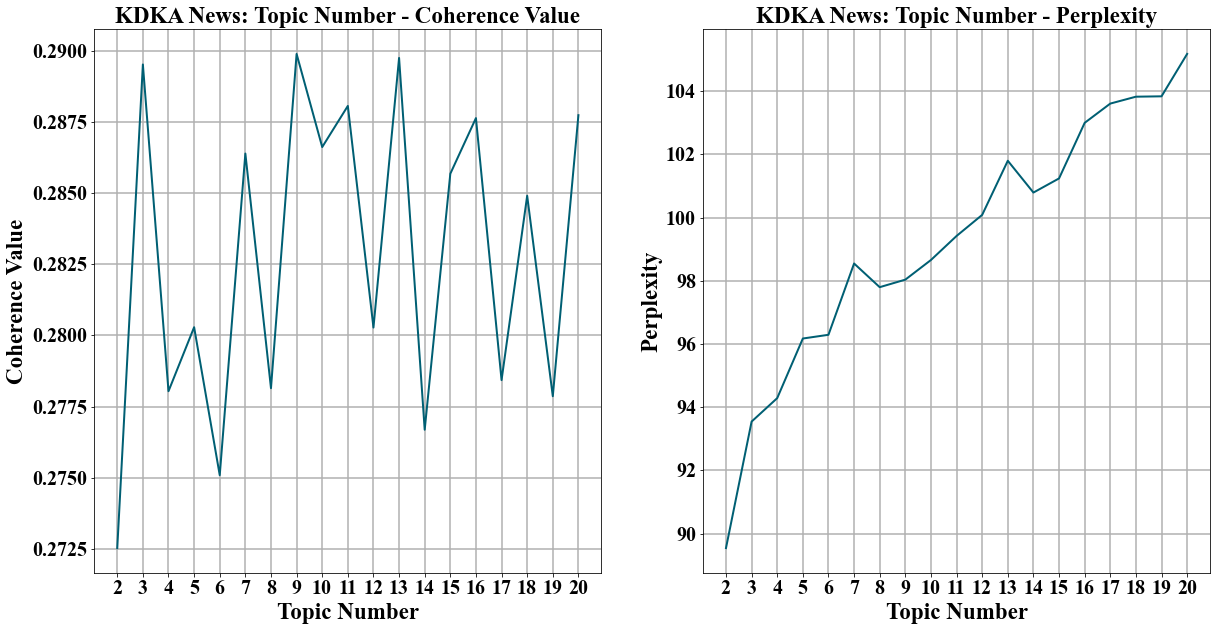

In [37]:
fig1 = plotScores(coherence_values1, plexs1)
if save_plot :
       fig1.savefig(r'./Plot/CBS_KDKA/cbs_LDA_topicnums1.jpg', bbox_inches = 'tight')

documents 1 : 3 8

In [39]:
# Document 2
coherence_values2 = compute_coherence_values(documents2, no_below=10, no_above=0.8, end=20)
plexs2 = compute_Perplexity(documents2, n_min=10, n_max=0.8, n_keyterms = 100, end=20)

100%|██████████████████████████████████████████████████████████████████████████████████| 19/19 [02:30<00:00,  7.94s/it]


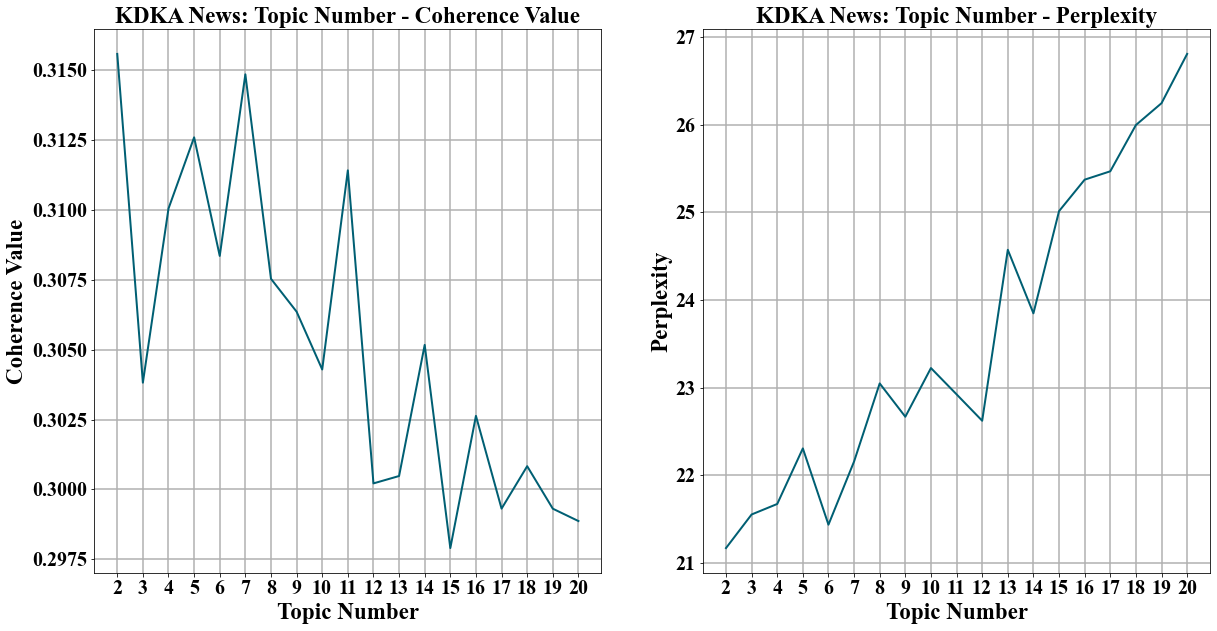

In [40]:
fig2 = plotScores(coherence_values2, plexs2)
if save_plot :
       fig2.savefig(r'./Plot/CBS_KDKA/cbs_LDA_topicnums2.jpg', bbox_inches = 'tight')

documents 2 : 5 6 7 8

In [41]:
# Document 3
coherence_values3 = compute_coherence_values(documents3, no_below=10, no_above=0.8, end=20)
plexs3 = compute_Perplexity(documents3, n_min=10, n_max=0.8, n_keyterms = 100, end=20)

100%|██████████████████████████████████████████████████████████████████████████████████| 19/19 [09:41<00:00, 30.62s/it]


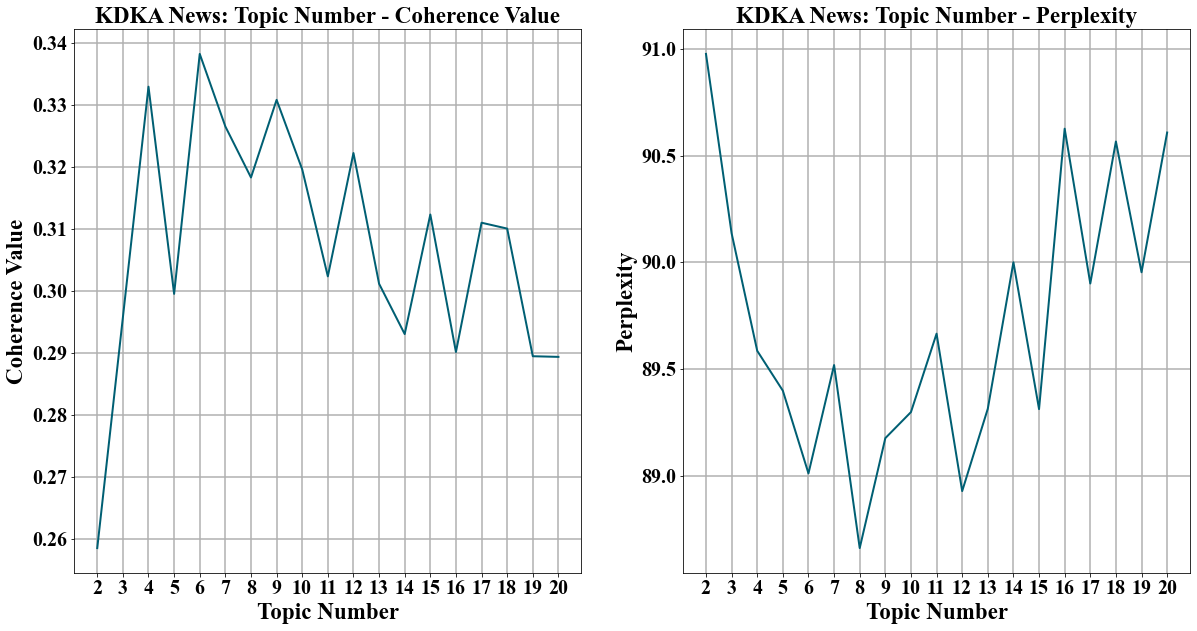

In [42]:
fig3 = plotScores(coherence_values3, plexs3)
if save_plot :
       fig3.savefig(r'./Plot/CBS_KDKA/cbs_LDA_topicnums3.jpg', bbox_inches = 'tight')

documents 3 : 5 6 8 9 12

In [43]:
# Document 4
coherence_values4 = compute_coherence_values(documents4, no_below=10, no_above=0.8, end=20)
plexs4 = compute_Perplexity(documents4, n_min=10, n_max=0.8, n_keyterms = 100, end=20)

100%|██████████████████████████████████████████████████████████████████████████████████| 19/19 [04:06<00:00, 12.97s/it]


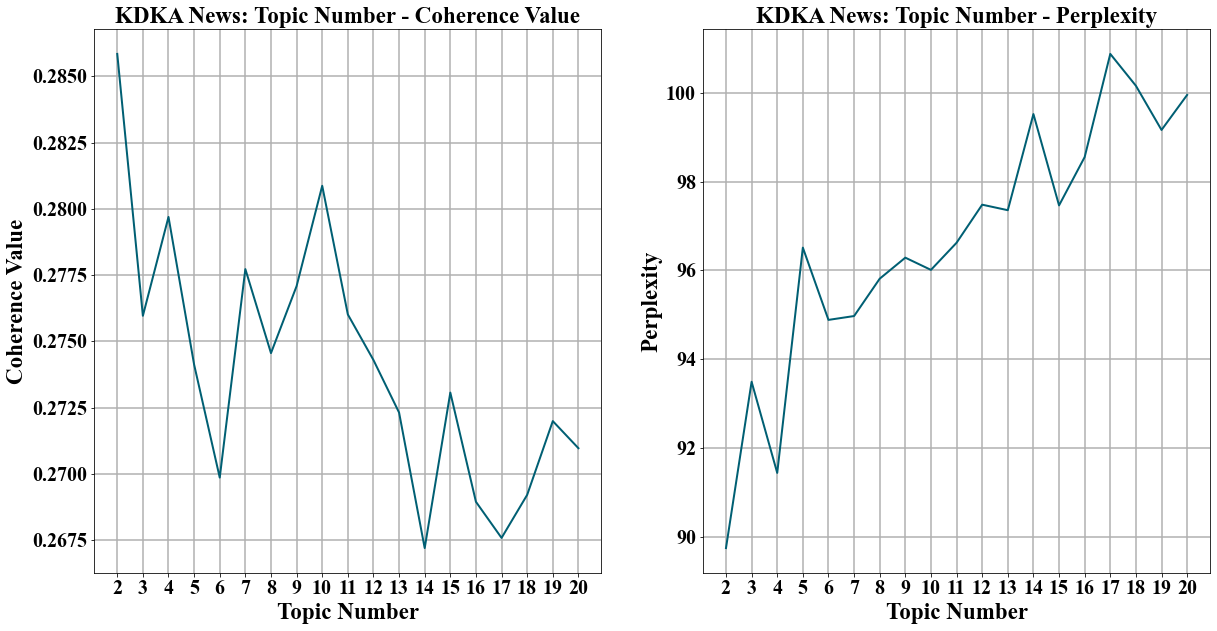

In [44]:
fig4 = plotScores(coherence_values4, plexs4)
if save_plot :
       fig4.savefig(r'./Plot/CBS_KDKA/cbs_LDA_topicnums4.jpg', bbox_inches = 'tight')

documents 4 : 4 7

documents 1 : 3 8

documents 2 : 5 6 7 8

documents 3 : 5 6 8 9 12

documents 4 : 4 7

### Other Parameters : GridSearchCV

In [42]:
# from sklearn.decomposition import LatentDirichletAllocation
# from sklearn.model_selection import GridSearchCV

In [72]:
# Add addtional Stopwords
stopwords = ['county','pennsylvania','virginia','additional','ohio','bringing',
             'week','year','fall','countywide','area','state','report','statewide',
            'amid', 'pittsburgh','covid','district','announces','west','local','center',
            'day','phase','virus','plan','beaver','pandemic','north','washington','link',
            'july','april','announced','percent','reporting','probable','month','thing','lot',
            'hour','hill','penn','city','bull','wear','wearing','staff','including','told',
            'august','decision','group','bar','high','stand','increase','june','needed','start',
            'today','feel','pennsylvanian','team','entire']

#### Documents 1

In [207]:
# Documents 1
documents = documents1

In [208]:
# Prepare vectorized document
n_keyterms = 50    # Number of key terms selected
n_min = 10         # Ignore terms that have a document frequency strictly lower than the given threshold
n_max = 0.8        # Ignore terms that have a document frequency strictly higher than the given threshold

tf_vectorizer = CountVectorizer(max_features = n_keyterms , 
                                min_df = n_min , max_df = n_max , stop_words=stopwords )
vectorized_documents = tf_vectorizer.fit_transform( documents )
keyterms1 = tf_vectorizer.get_feature_names_out() # Get keyterms

In [209]:
%%time
# Search Paraeters
topic_nums = [3,8]
alpha = [50/x for x in topic_nums]

search_params = { 'n_components'    : topic_nums,
                  'learning_decay'  : [.5, .7, .6, .7],
                  'doc_topic_prior' : alpha,                    # alpha 50/n_topics
                  'topic_word_prior': [0.01, 0.05, 0.1, 0.15]}  # beta 

# Set up LDA with the options we'll keep static
model = LatentDirichletAllocation(learning_method='online',max_iter=500)
# Init Grid Search Class
# Use verbose>0 to visualize the process, can be seen in he terminal window
gridsearch = GridSearchCV(model, param_grid = search_params, n_jobs = -1, verbose=2) 
# Do the Grid Search
gridsearch.fit(vectorized_documents)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Wall time: 3min 47s


GridSearchCV(estimator=LatentDirichletAllocation(learning_method='online',
                                                 max_iter=500),
             n_jobs=-1,
             param_grid={'doc_topic_prior': [16.666666666666668, 6.25],
                         'learning_decay': [0.5, 0.7, 0.6, 0.7],
                         'n_components': [3, 8],
                         'topic_word_prior': [0.01, 0.05, 0.1, 0.15]},
             verbose=2)

In [210]:
# Get best Model
best_lda1 = gridsearch.best_estimator_

# What did we find?
print("Documents1, Best Model's Params: ", gridsearch.best_params_)
print("Documents1, Best Log Likelihood Score: ", gridsearch.best_score_) # higher, better
print("Documents1, Model Perplexity: ", best_lda1.perplexity(vectorized_documents))

Documents1, Best Model's Params:  {'doc_topic_prior': 6.25, 'learning_decay': 0.5, 'n_components': 3, 'topic_word_prior': 0.15}
Documents1, Best Log Likelihood Score:  -2464.233026111187
Documents1, Model Perplexity:  43.55261244973223


#### Documents 2

In [211]:
# Documents 2
documents = documents2

In [212]:
# Prepare vectorized document
n_keyterms = 50    # Number of key terms selected
n_min = 10         # Ignore terms that have a document frequency strictly lower than the given threshold
n_max = 0.8         # Ignore terms that have a document frequency strictly higher than the given threshold

tf_vectorizer = CountVectorizer(max_features = n_keyterms , 
                                min_df = n_min , max_df = n_max , stop_words=stopwords  )
vectorized_documents = tf_vectorizer.fit_transform( documents )
keyterms2 = tf_vectorizer.get_feature_names_out() # Get keyterms

In [213]:
%%time
# Search Paraeters
topic_nums = [5,6,7,8]
alpha = [50/x for x in topic_nums]

search_params = { 'n_components'    : topic_nums,
                  'learning_decay'  : [.5, .7, .6, .7],
                  'doc_topic_prior' : alpha,                   # alpha 50/n_topics
                  'topic_word_prior': [0.01, 0.05, 0.1, 0.15]} # beta

# Set up LDA with the options we'll keep static
model = LatentDirichletAllocation(learning_method='online',max_iter=500)
# Init Grid Search Class
gridsearch = GridSearchCV(model, param_grid = search_params, n_jobs = -1, verbose=2)
# Do the Grid Search
gridsearch.fit(vectorized_documents)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Wall time: 10min 4s


GridSearchCV(estimator=LatentDirichletAllocation(learning_method='online',
                                                 max_iter=500),
             n_jobs=-1,
             param_grid={'doc_topic_prior': [10.0, 8.333333333333334,
                                             7.142857142857143,
                                             5.555555555555555],
                         'learning_decay': [0.5, 0.7, 0.6, 0.7],
                         'n_components': [5, 6, 7, 9],
                         'topic_word_prior': [0.01, 0.05, 0.1, 0.15]},
             verbose=2)

In [214]:
# Get best Model
best_lda2 = gridsearch.best_estimator_

# What did we find?
print("Documents2, Best Model's Params: ", gridsearch.best_params_)
print("Documents2, Best Log Likelihood Score: ", gridsearch.best_score_)
print("Documents2, Model Perplexity: ", best_lda2.perplexity(vectorized_documents))

Documents2, Best Model's Params:  {'doc_topic_prior': 5.555555555555555, 'learning_decay': 0.5, 'n_components': 5, 'topic_word_prior': 0.1}
Documents2, Best Log Likelihood Score:  -280.65361271169917
Documents2, Model Perplexity:  16.654093416900416


#### Documents 3

In [215]:
# Documents 3
documents = documents3

In [216]:
# Prepare vectorized document
n_keyterms = 50    # Number of key terms selected
n_min = 10         # Ignore terms that have a document frequency strictly lower than the given threshold
n_max = 0.8       # Ignore terms that have a document frequency strictly higher than the given threshold

tf_vectorizer = CountVectorizer(max_features = n_keyterms , 
                                min_df = n_min , max_df = n_max , stop_words=stopwords  )
vectorized_documents = tf_vectorizer.fit_transform( documents )
keyterms3 = tf_vectorizer.get_feature_names_out() # Get keyterms

In [217]:
%%time
# Search Paraeters
topic_nums = [5,6,8,9,12]
alpha = [50/x for x in topic_nums]

search_params = { 'n_components'    : topic_nums,
                  'learning_decay'  : [.5, .7, .6, .7],
                  'doc_topic_prior' : alpha,                   # alpha 50/n_topics
                  'topic_word_prior': [0.01, 0.05, 0.1, 0.15]}  # beta

# Set up LDA with the options we'll keep static
model = LatentDirichletAllocation(learning_method='online',max_iter=500)
# Init Grid Search Class
gridsearch = GridSearchCV(model, param_grid = search_params, n_jobs = -1, verbose=2)
# Do the Grid Search
gridsearch.fit(vectorized_documents)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Wall time: 46min 16s


GridSearchCV(estimator=LatentDirichletAllocation(learning_method='online',
                                                 max_iter=500),
             n_jobs=-1,
             param_grid={'doc_topic_prior': [10.0, 7.142857142857143, 6.25,
                                             5.555555555555555,
                                             4.545454545454546],
                         'learning_decay': [0.5, 0.7, 0.6, 0.7],
                         'n_components': [5, 7, 8, 9, 11],
                         'topic_word_prior': [0.01, 0.05, 0.1, 0.15]},
             verbose=2)

In [218]:
# Get best Model
best_lda3 = gridsearch.best_estimator_

# What did we find?
print("Documents3, Best Model's Params: ", gridsearch.best_params_)
print("Documents3, Best Log Likelihood Score: ", gridsearch.best_score_)
print("Documents3, Model Perplexity: ", best_lda3.perplexity(vectorized_documents))

Documents3, Best Model's Params:  {'doc_topic_prior': 4.545454545454546, 'learning_decay': 0.5, 'n_components': 5, 'topic_word_prior': 0.15}
Documents3, Best Log Likelihood Score:  -15705.482059225416
Documents3, Model Perplexity:  42.43833887701525


#### Documents 4

In [219]:
# Documents 4
documents = documents4

In [220]:
# Prepare vectorized document
n_keyterms = 50    # Number of key terms selected
n_min = 10         # Ignore terms that have a document frequency strictly lower than the given threshold
n_max = 0.8        # Ignore terms that have a document frequency strictly higher than the given threshold

tf_vectorizer = CountVectorizer(max_features = n_keyterms , 
                                min_df = n_min , max_df = n_max , stop_words=stopwords  )
vectorized_documents = tf_vectorizer.fit_transform( documents )
keyterms4 = tf_vectorizer.get_feature_names_out() # Get keyterms

In [221]:
%%time
# Search Paraeters
topic_nums = [4,5,6,7]
alpha = [50/x for x in topic_nums]

search_params = { 'n_components'    : topic_nums,
                  'learning_decay'  : [.5, .7, .6, .7],
                  'doc_topic_prior' : alpha,                    # alpha 50/n_topics
                  'topic_word_prior': [0.01, 0.05, 0.1, 0.15]}  # beta

# Set up LDA with the options we'll keep static
model = LatentDirichletAllocation(learning_method='online',max_iter=500)
# Init Grid Search Class
gridsearch = GridSearchCV(model, param_grid = search_params, n_jobs = -1, verbose=2)
# Do the Grid Search
gridsearch.fit(vectorized_documents)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Wall time: 8min 45s


GridSearchCV(estimator=LatentDirichletAllocation(learning_method='online',
                                                 max_iter=500),
             n_jobs=-1,
             param_grid={'doc_topic_prior': [12.5, 10.0, 8.333333333333334],
                         'learning_decay': [0.5, 0.7, 0.6, 0.7],
                         'n_components': [4, 5, 6],
                         'topic_word_prior': [0.01, 0.05, 0.1, 0.15]},
             verbose=2)

In [222]:
# Get best Model
best_lda4 = gridsearch.best_estimator_

# What did we find?
print("Documents4, Best Model's Params: ", gridsearch.best_params_)
print("Documents4, Best Log Likelihood Score: ", gridsearch.best_score_)
print("Documents4, Model Perplexity: ", best_lda4.perplexity(vectorized_documents))

Documents4, Best Model's Params:  {'doc_topic_prior': 8.333333333333334, 'learning_decay': 0.5, 'n_components': 4, 'topic_word_prior': 0.1}
Documents4, Best Log Likelihood Score:  -2664.9367776651525
Documents4, Model Perplexity:  43.91184302808175


In [223]:
# Save LDAModels
import pickle

LDAModels = [best_lda1, best_lda2, best_lda3, best_lda4]

if True :
    for lda in LDAModels :
        filename = './Data/CBS_KDKA/LDA/LDA%d.pkl'%(LDAModels.index(lda)+1)
        with open(filename, 'wb') as file:
            pickle.dump(lda, file)

In [224]:
LDAModels

[LatentDirichletAllocation(doc_topic_prior=6.25, learning_decay=0.5,
                          learning_method='online', max_iter=500,
                          n_components=3, topic_word_prior=0.15), LatentDirichletAllocation(doc_topic_prior=5.555555555555555, learning_decay=0.5,
                          learning_method='online', max_iter=500,
                          n_components=5, topic_word_prior=0.1), LatentDirichletAllocation(doc_topic_prior=4.545454545454546, learning_decay=0.5,
                          learning_method='online', max_iter=500,
                          n_components=5, topic_word_prior=0.15), LatentDirichletAllocation(doc_topic_prior=8.333333333333334, learning_decay=0.5,
                          learning_method='online', max_iter=500,
                          n_components=4, topic_word_prior=0.1)]

Documents1, Best Log Likelihood Score:  -2464.233026111187, Model Perplexity:  43.55261244973223

Documents2, Best Log Likelihood Score:  -280.6536127116992, Model Perplexity:  16.654093416900416

Documents3, Best Log Likelihood Score:  -15705.48205922542, Model Perplexity:  42.43833887701525

Documents4, Best Log Likelihood Score:  -2664.936777665152, Model Perplexity:  43.91184302808175

## LDA Model: Topic with Top Words

In [15]:
# Notes --- Apply LDA
# https://stats.stackexchange.com/questions/59684/what-are-typical-values-to-use-for-alpha-and-beta-in-latent-dirichlet-allocation

'''
n_topics = 5 # Number of topics

lda = LatentDirichletAllocation(n_components = n_topics,
                                doc_topic_prior  = 50/n_topics,    # alpha
                                topic_word_prior = 0.1,   # beta
                                learning_method='batch',
                                learning_offset = 50.0, 
                                max_iter = 50)

lda.fit(tf) # tf is the sparse matrix from the CountVectorizer model

''';

### Additional Stopwords

In [16]:
# Add addtional Stopwords
# Visualiztion
import pyLDAvis
import pyLDAvis.sklearn

stopwords = ['county','pennsylvania','virginia','additional','ohio','bringing',
             'week','year','fall','countywide','area','state','report','statewide',
            'amid', 'pittsburgh','covid','district','announces','west','local','center',
            'day','phase','virus','plan','beaver','pandemic','north','washington','link',
            'july','april','announced','percent','reporting','probable','month','thing','lot',
            'hour','hill','penn','city','bull','wear','wearing','staff','including','told',
            'august','decision','group','bar','high','stand','increase','june','needed','start',
            'today','feel','pennsylvanian','team','entire']

In [17]:
# Load the saved model and data
import pickle
# Read data
cbs       = pd.read_csv('./Data/CBS_KDKA/cbs_clean.csv', encoding = "utf_8_sig")
cbs_list1 = pd.read_csv('./Data/CBS_KDKA/cbs_title.csv', encoding = "utf_8_sig")
cbs_list2 = pd.read_csv('./Data/CBS_KDKA/cbs_keywords.csv', encoding = "utf_8_sig")
cbs_list3 = pd.read_csv('./Data/CBS_KDKA/cbs_content.csv', encoding = "utf_8_sig")
cbs_list4 = pd.read_csv('./Data/CBS_KDKA/cbs_selectedwords.csv', encoding = "utf_8_sig")

cbs_list1.set_index('Date', inplace = True) # Title
cbs_list2.set_index('Date', inplace = True) # Keywords
cbs_list3.set_index('Date', inplace = True) # Content
cbs_list4.set_index('Date', inplace = True) # Selectedwords

days = list(cbs_list1.index)

# Get (daily) document set
documents1 = list(cbs_list1.iloc[:,0])
documents2 = list(cbs_list2.iloc[:,0])
documents3 = list(cbs_list3.iloc[:,0])
documents4 = list(cbs_list4.iloc[:,0])

documents = [documents1, documents2, documents3, documents4]

# Load the saved model
LDAModels = []
tfs = []
tf_vectorizers = []
keyterms = []
n_maxs = [0.8,0.8,0.8,0.8] #[219, 64, 1731, 649]

for i in range(4) :
    filename = './Data/CBS_KDKA/LDA/LDA%d.pkl'%(i+1)
    with open(filename, 'rb') as file:
        LDAModels.append(pickle.load(file))  

    # Prepare vectorized document
    n_keyterms = 50     # Number of key terms selected
    n_min = 10          # Ignore terms that have a document frequency strictly lower than the given threshold
    n_max = n_maxs[i]   # Ignore terms that have a document frequency strictly higher than the given threshold

    vectorizer = CountVectorizer(max_features = n_keyterms , 
                                    min_df = n_min , max_df = n_max , stop_words=stopwords  )
    tf = vectorizer.fit_transform( documents[i] )
    tf_vectorizers.append(vectorizer)
    tfs.append(tf)
    keyterms.append(vectorizer.get_feature_names_out()) # Get keyterms


In [18]:
display(LDAModels)
display(tfs)
display(tf_vectorizers)
display(keyterms)

[LatentDirichletAllocation(doc_topic_prior=6.25, learning_decay=0.5,
                          learning_method='online', max_iter=1500,
                          n_components=3, topic_word_prior=0.15), LatentDirichletAllocation(doc_topic_prior=5.555555555555555, learning_decay=0.5,
                          learning_method='online', max_iter=500,
                          n_components=5, topic_word_prior=0.1), LatentDirichletAllocation(doc_topic_prior=4.545454545454546, learning_decay=0.5,
                          learning_method='online', max_iter=500,
                          n_components=5, topic_word_prior=0.15), LatentDirichletAllocation(doc_topic_prior=8.333333333333334, learning_decay=0.5,
                          learning_method='online', max_iter=500,
                          n_components=4, topic_word_prior=0.1)]

[<181x50 sparse matrix of type '<class 'numpy.int64'>'
	with 2116 stored elements in Compressed Sparse Row format>, <181x16 sparse matrix of type '<class 'numpy.int64'>'
	with 302 stored elements in Compressed Sparse Row format>, <181x50 sparse matrix of type '<class 'numpy.int64'>'
	with 6055 stored elements in Compressed Sparse Row format>, <181x50 sparse matrix of type '<class 'numpy.int64'>'
	with 2136 stored elements in Compressed Sparse Row format>]

[CountVectorizer(max_df=0.8, max_features=50, min_df=10,
                stop_words=['county', 'pennsylvania', 'virginia', 'additional',
                            'ohio', 'bringing', 'week', 'year', 'fall',
                            'countywide', 'area', 'state', 'report',
                            'statewide', 'amid', 'pittsburgh', 'covid',
                            'district', 'announces', 'west', 'local', 'center',
                            'day', 'phase', 'virus', 'plan', 'beaver',
                            'pandemic', 'north', 'washington', ...]), CountVectorizer(max_df=0.8, max_features=50, min_df=10,
                stop_words=['county', 'pennsylvania', 'virginia', 'additional',
                            'ohio', 'bringing', 'week', 'year', 'fall',
                            'countywide', 'area', 'state', 'report',
                            'statewide', 'amid', 'pittsburgh', 'covid',
                            'district', 'announces', 'west', 'local', 'center',


[array(['authority', 'business', 'cancel', 'child', 'class', 'climb',
       'close', 'community', 'confirms', 'death', 'doctor', 'employee',
       'family', 'food', 'gov', 'government', 'hospital', 'mask',
       'nursing', 'official', 'order', 'outbreak', 'owner', 'patient',
       'people', 'police', 'port', 'positive', 'public', 'reopen',
       'resident', 'restaurant', 'restriction', 'return', 'rise',
       'safety', 'school', 'stay', 'store', 'student', 'test', 'testing',
       'time', 'toll', 'tomwolf', 'university', 'upmc', 'wolf', 'worker',
       'yellow'], dtype=object), array(['amp', 'butler', 'fayette', 'football', 'hockey', 'mlb', 'nfl',
       'nhl', 'number', 'oakland', 'penguin', 'pirate', 'school',
       'steelers', 'unemployment', 'westmoreland'], dtype=object), array(['breakdown', 'business', 'child', 'class', 'company', 'concern',
       'contact', 'customer', 'developing', 'effort', 'emergency', 'food',
       'gov', 'green', 'guideline', 'home', 'levine', 'l

In [19]:
# Model result
lda = LDAModels[0]

# model.components_ 
display( lda.components_ )

'''
model.components_[i, j] :（pseudocount）the number of times word j was assigned to topic i
model.components_ / model.components_.sum(axis=1)[:, np.newaxis] ： the proportion of word j in topic i
line i for topic, column j for key feature / term

pseudocount :
A pseudocount is an amount (not generally an integer, despite its name) added to the number of observed
cases in order to change the expected probability in a model of those data, when not known to be zero.
https://www.zhihu.com/question/23405711

'''

# model.n_features_in_
display( lda.n_features_in_ )   # Number of features / keyterms

# model.perplexity(tf)
# tf is the sparse matrix from the CountVectorizer model
display( lda.perplexity(tf) )   # calculate the model perplexity

# model.transform(tf)
# tf is the sparse matrix from the CountVectorizer model
display( lda.transform(tf) )   # The topics associated with the documents


'''  model.transform(tf) = 

               ( 2Darray )      Topic 0         Topic 1        Topic 2      ....
                document 0    percent(0,0)   percent(0,1)   percent(0,2)
                document 1    percent(1,0)   percent(1,1)   percent(1,2)
                document 2    percent(2,0)   percent(2,1)   percent(2,2)
                .
                .
                .

'''

array([[1.46112776e+01, 1.50899673e-01, 1.50888640e-01, 1.50870606e-01,
        1.50799282e-01, 1.50960923e-01, 1.23790473e+02, 3.23161816e+01,
        2.39664885e+01, 1.50801630e-01, 1.50947975e-01, 8.16049749e+01,
        1.50898881e-01, 1.50906844e-01, 1.50822908e-01, 1.51077042e-01,
        1.50927367e-01, 7.62105707e+01, 1.50907730e-01, 2.46108914e+01,
        1.50659402e-01, 1.50950529e-01, 6.44849840e+01, 1.50853735e-01,
        2.90799003e+01, 4.99835198e+01, 3.22042562e+01, 1.68328962e+02,
        1.50843613e-01, 1.50737689e-01, 1.50993850e-01, 1.26386261e+01,
        1.50803813e-01, 1.50727303e-01, 1.50816614e-01, 1.50645855e-01,
        1.50774407e-01, 1.50867907e-01, 1.50981716e-01, 1.50703078e-01,
        1.68861027e+02, 3.74789182e+01, 1.50893887e-01, 1.50693670e-01,
        1.50719404e-01, 1.50811536e-01, 1.50930613e-01, 1.50861098e-01,
        1.50888979e-01, 1.50539846e-01],
       [1.25178082e+01, 6.60956775e+01, 1.50750736e-01, 1.50751505e-01,
        1.50830148e-01,

50

57.38708250270076

array([[0.31645754, 0.36708483, 0.31645762],
       [0.33333505, 0.33333086, 0.33333409],
       [0.36263952, 0.36263194, 0.27472854],
       [0.30841142, 0.38317432, 0.30841427],
       [0.3737366 , 0.37373525, 0.25252816],
       [0.33756685, 0.36201369, 0.30041947],
       [0.30841129, 0.38317484, 0.30841387],
       [0.26316098, 0.3052611 , 0.43157792],
       [0.27407249, 0.36296006, 0.36296745],
       [0.23919208, 0.50639014, 0.25441778],
       [0.27826898, 0.50179384, 0.21993718],
       [0.2163761 , 0.59063976, 0.19298414],
       [0.22388831, 0.50862017, 0.26749153],
       [0.23472047, 0.58078553, 0.184494  ],
       [0.26574088, 0.4825049 , 0.25175422],
       [0.2290514 , 0.4930126 , 0.277936  ],
       [0.23637886, 0.49612683, 0.26749431],
       [0.161174  , 0.5619368 , 0.27688919],
       [0.26315702, 0.55311027, 0.18373271],
       [0.21517837, 0.46760398, 0.31721766],
       [0.19618297, 0.62762235, 0.17619468],
       [0.37814846, 0.33579136, 0.28606018],
       [0.

'  model.transform(tf) = \n\n               ( 2Darray )      Topic 0         Topic 1        Topic 2      ....\n                document 0    percent(0,0)   percent(0,1)   percent(0,2)\n                document 1    percent(1,0)   percent(1,1)   percent(1,2)\n                document 2    percent(2,0)   percent(2,1)   percent(2,2)\n                .\n                .\n                .\n\n'

In [20]:
# Define a function to print the top words in each topic
def print_top_words( model , feature_names , n_top_words ):
    
    '''
    Return a list of dictionaries, with key being the keyterm and value being the corresponding percentage
    '''
    
    tword = []
    percent_component = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    for topic_id, topic in enumerate(percent_component):
        
        topic_w = { feature_names[i] : [round(topic[i],3),] for i in topic.argsort()[-1::-1][:n_top_words] }
        tword.append(topic_w)
        
        total_percent = sum([topic[i] for i in topic.argsort()[-1::-1][:n_top_words]])*100
        
        print('Topic #%d' % (topic_id+1), ':' , '%.2f'%total_percent , '%' )
        print(topic_w)
        print(' ')
    
    return tword


# Define a function to print the percent for top words in each topic
def top_words_percent( model , n_top_words ):
    percent = []
    percent_component = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    for topic in percent_component:     
        total_percent = sum([topic[i] for i in topic.argsort()[-1::-1][:n_top_words]])
        percent.append(total_percent)
    return np.array(percent)


# Train New Model
def NewLDA( index , topicNum = -1, maxIter = -1, update = False ):
    # index is the document index - 1
    doc_topic_priors  = [6.25, 5.555555555555555, 4.545454545454546, 8.333333333333334]
    learning_decays   = [0.5, 0.5, 0.5, 0.5]
    topic_word_priors = [0.15, 0.1, 0.15, 0.15]
    topic_nums        = [3, 5, 5, 4]
    max_iters         = [500, 500, 500, 500]
    
    if topicNum > 0 :
        topic_nums[index] = topicNum
    if maxIter > 0 :
        max_iters [index] = maxIter
    
    lda = LatentDirichletAllocation(doc_topic_prior=doc_topic_priors[index], 
                                    learning_decay=learning_decays[index] ,
                                    learning_method='online', 
                                    max_iter=max_iters[index],
                                    n_components=topic_nums[index], 
                                    topic_word_prior=topic_word_priors[index])
    lda.fit(tfs[index])
    perp = lda.perplexity(tfs[index])
    score  = lda.score(tfs[index])
    
    print("Documents%d, Best Log Likelihood Score: "%(index+1),score)
    print("Documents%d, Model Perplexity: "%(index+1),perp)
    
    if update:
        filename = './Data/CBS_KDKA/LDA/adjusted_LDA%d.pkl'%(index+1)
        with open(filename, 'wb') as file:
            pickle.dump(lda, file)
            
        pyLDAvis.enable_notebook();
        pic = pyLDAvis.sklearn.prepare(lda, tfs[index], tf_vectorizers[index]);
        pyLDAvis.display(pic);
        pyLDAvis.save_html(pic,'./Data/CBS_KDKA/LDA/adjusted_cbs_lda_visual%d.html'%(index+1)); # open lda.html in the working dictionary

    return lda


### Documents 1

In [148]:
# Notes --- Apply LDA
# https://stats.stackexchange.com/questions/59684/what-are-typical-values-to-use-for-alpha-and-beta-in-latent-dirichlet-allocation

'''
n_topics = 5 # Number of topics

lda = LatentDirichletAllocation(n_components = n_topics,
                                doc_topic_prior  = 50/n_topics,    # alpha
                                topic_word_prior = 0.1,   # beta
                                learning_method='batch',
                                learning_offset = 50.0, 
                                max_iter = 50)

lda.fit(tf) # tf is the sparse matrix from the CountVectorizer model

''';

In [165]:
%%time
LDAModels[0] = NewLDA( 0 , topicNum = -1, maxIter = 5000, update = True );

Documents1, Best Log Likelihood Score:  -11068.015309431481
Documents1, Model Perplexity:  43.481244737013895


D:\Anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
D:\Anaconda3\lib\site-packages\pyLDAvis\_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


Wall time: 46.6 s


In [166]:
cbs_topic_dics1 = print_top_words( LDAModels[0] , keyterms[0] , n_top_words = 10 )

Topic #1 : 64.22 %
{'close': [0.122], 'reopen': [0.096], 'gov': [0.089], 'business': [0.065], 'outbreak': [0.064], 'order': [0.048], 'food': [0.045], 'tomwolf': [0.044], 'wolf': [0.035], 'doctor': [0.033]}
 
Topic #2 : 84.55 %
{'test': [0.186], 'positive': [0.185], 'employee': [0.09], 'mask': [0.084], 'worker': [0.06], 'people': [0.055], 'testing': [0.055], 'hospital': [0.047], 'climb': [0.044], 'government': [0.04]}
 
Topic #3 : 90.00 %
{'school': [0.28], 'death': [0.136], 'student': [0.126], 'university': [0.072], 'restaurant': [0.065], 'return': [0.051], 'public': [0.049], 'restriction': [0.044], 'child': [0.042], 'cancel': [0.036]}
 


Topic1: Close & Open policies

Topic2: Medical, Test count & Safety 

Topic3: School & University

In [167]:
if save_data :
    for topic in cbs_topic_dics1 :
        topic_index = 'Topic_%d' % (cbs_topic_dics1.index(topic)+1)
        pd.DataFrame(topic, index = [topic_index,]).to_csv('./Data/CBS_KDKA/LDA/Title/cbsTopicTopWords_'+ topic_index + '.csv', encoding = "utf_8_sig" ,  index = False)

### Documents 2

In [168]:
%%time
LDAModels[1] = NewLDA( 1 , topicNum = -1, maxIter = 1000, update = True );

Documents2, Best Log Likelihood Score:  -1047.3983124410634
Documents2, Model Perplexity:  16.57736766060146
Wall time: 9.03 s


In [169]:
cbs_topic_dics2 = print_top_words( LDAModels[1] , keyterms[1] , n_top_words = 10 )

Topic #1 : 99.11 %
{'penguin': [0.297], 'unemployment': [0.261], 'nhl': [0.245], 'hockey': [0.178], 'school': [0.001], 'westmoreland': [0.001], 'football': [0.001], 'steelers': [0.001], 'nfl': [0.001], 'oakland': [0.001]}
 
Topic #2 : 99.24 %
{'butler': [0.305], 'amp': [0.288], 'westmoreland': [0.271], 'number': [0.121], 'school': [0.001], 'steelers': [0.001], 'football': [0.001], 'nfl': [0.001], 'fayette': [0.001], 'unemployment': [0.001]}
 
Topic #3 : 99.38 %
{'football': [0.372], 'steelers': [0.325], 'nfl': [0.289], 'school': [0.001], 'oakland': [0.001], 'westmoreland': [0.001], 'butler': [0.001], 'amp': [0.001], 'fayette': [0.001], 'unemployment': [0.001]}
 
Topic #4 : 99.12 %
{'pirate': [0.291], 'mlb': [0.271], 'fayette': [0.241], 'oakland': [0.179], 'school': [0.001], 'football': [0.001], 'steelers': [0.001], 'butler': [0.001], 'westmoreland': [0.001], 'nfl': [0.001]}
 
Topic #5 : 99.41 %
{'school': [0.985], 'football': [0.001], 'steelers': [0.001], 'nfl': [0.001], 'westmoreland'

In [170]:
if save_data :
    for topic in cbs_topic_dics2 :
        topic_index = 'Topic_%d' % (cbs_topic_dics2.index(topic)+1)
        pd.DataFrame(topic, index = [topic_index,]).to_csv('./Data/CBS_KDKA/LDA/Keyword/cbsTopicTopWords_'+ topic_index + '.csv', encoding = "utf_8_sig" ,  index = False)

### Documents 3

In [32]:
LDAModels[2] = NewLDA( 2 , topicNum = -1, maxIter = 5000, update = True );

Documents3, Best Log Likelihood Score:  -75310.68148857002
Documents3, Model Perplexity:  42.251244821561805


In [33]:
cbs_topic_dics3 = print_top_words( LDAModels[2] , keyterms[2] , n_top_words = 10 )

Topic #1 : 93.96 %
{'school': [0.33], 'student': [0.244], 'university': [0.085], 'child': [0.072], 'class': [0.065], 'online': [0.064], 'concern': [0.028], 'contact': [0.018], 'risk': [0.018], 'spread': [0.016]}
 
Topic #2 : 66.53 %
{'testing': [0.133], 'food': [0.095], 'symptom': [0.077], 'spread': [0.067], 'medical': [0.065], 'outbreak': [0.055], 'service': [0.047], 'emergency': [0.047], 'public': [0.042], 'risk': [0.038]}
 
Topic #3 : 77.32 %
{'restaurant': [0.175], 'store': [0.127], 'company': [0.104], 'customer': [0.096], 'order': [0.069], 'restriction': [0.062], 'public': [0.04], 'office': [0.039], 'business': [0.033], 'child': [0.028]}
 
Topic #4 : 83.85 %
{'nursing': [0.13], 'older': [0.11], 'breakdown': [0.107], 'personal': [0.102], 'toll': [0.089], 'home': [0.086], 'green': [0.075], 'levine': [0.049], 'president': [0.048], 'safety': [0.043]}
 
Topic #5 : 77.35 %
{'business': [0.171], 'open': [0.097], 'order': [0.097], 'wolf': [0.092], 'gov': [0.089], 'park': [0.055], 'yellow'

In [34]:
if save_data :
    for topic in cbs_topic_dics3 :
        topic_index = 'Topic_%d' % (cbs_topic_dics3.index(topic)+1)
        pd.DataFrame(topic, index = [topic_index,]).to_csv('./Data/CBS_KDKA/LDA/Content/cbsTopicTopWords_'+ topic_index + '.csv', encoding = "utf_8_sig" ,  index = False)

### Documents 4

In [62]:
%%time
LDAModels[3] = NewLDA( 3 , topicNum = -1, maxIter = 1000, update = True );

Documents4, Best Log Likelihood Score:  -11893.031271848147
Documents4, Model Perplexity:  43.72693136035049
Wall time: 8.65 s


D:\Anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
D:\Anaconda3\lib\site-packages\pyLDAvis\_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


In [63]:
cbs_topic_dics4 = print_top_words( LDAModels[3] , keyterms[3] , n_top_words = 10 )

Topic #1 : 99.27 %
{'school': [0.434], 'student': [0.14], 'university': [0.097], 'football': [0.07], 'steelers': [0.068], 'return': [0.057], 'nfl': [0.046], 'cancel': [0.04], 'public': [0.038], 'child': [0.002]}
 
Topic #2 : 74.42 %
{'close': [0.159], 'gov': [0.115], 'business': [0.084], 'outbreak': [0.082], 'order': [0.062], 'tomwolf': [0.057], 'westmoreland': [0.049], 'police': [0.047], 'wolf': [0.046], 'toll': [0.042]}
 
Topic #3 : 93.97 %
{'test': [0.221], 'positive': [0.22], 'employee': [0.107], 'worker': [0.071], 'food': [0.061], 'butler': [0.058], 'hospital': [0.055], 'child': [0.051], 'pirate': [0.049], 'government': [0.047]}
 
Topic #4 : 84.18 %
{'death': [0.207], 'reopen': [0.132], 'mask': [0.103], 'restaurant': [0.081], 'testing': [0.067], 'restriction': [0.054], 'climb': [0.053], 'unemployment': [0.052], 'nursing': [0.048], 'doctor': [0.045]}
 


Topic1: School & University Life

Topic2: Outbreak, Close & Gov Policy

Topic3: Test count & Work

Topic4: Reopen & Safety & Restaurant

In [64]:
if save_data :
    for topic in cbs_topic_dics4 :
        topic_index = 'Topic_%d' % (cbs_topic_dics4.index(topic)+1)
        pd.DataFrame(topic, index = [topic_index,]).to_csv('./Data/CBS_KDKA/LDA/KeywordAndTitle/cbsTopicTopWords_'+ topic_index + '.csv', encoding = "utf_8_sig" ,  index = False)

In [54]:
# Visualiztion
import pyLDAvis
import pyLDAvis.sklearn

for i in range(4):
    pyLDAvis.enable_notebook()
    pic = pyLDAvis.sklearn.prepare(LDAModels[i], tfs[i], tf_vectorizers[i])
    pyLDAvis.display(pic)
    pyLDAvis.save_html(pic,'./Data/CBS_KDKA/LDA/cbs_lda_visual%d.html'%(i+1)) # open lda.html in the working dictionary
    print('Finish %d'%(i+1))

Finish 1
Finish 2
Finish 3
Finish 4


## Topic Associations with the Documents

### Data

In [65]:
# Load the saved model and data
import pickle

stopwords = ['county','pennsylvania','virginia','additional','ohio','bringing',
             'week','year','fall','countywide','area','state','report','statewide',
            'amid', 'pittsburgh','covid','district','announces','west','local','center',
            'day','phase','virus','plan','beaver','pandemic','north','washington','link',
            'july','april','announced','percent','reporting','probable','month','thing','lot',
            'hour','hill','penn','city','bull','wear','wearing','staff','including','told',
            'august','decision','group','bar','high','stand','increase','june','needed','start',
            'today','feel','pennsylvanian','team','entire']

# Read data
cbs       = pd.read_csv('./Data/CBS_KDKA/cbs_clean.csv', encoding = "utf_8_sig")
cbs_list1 = pd.read_csv('./Data/CBS_KDKA/cbs_title.csv', encoding = "utf_8_sig")
cbs_list2 = pd.read_csv('./Data/CBS_KDKA/cbs_keywords.csv', encoding = "utf_8_sig")
cbs_list3 = pd.read_csv('./Data/CBS_KDKA/cbs_content.csv', encoding = "utf_8_sig")
cbs_list4 = pd.read_csv('./Data/CBS_KDKA/cbs_selectedwords.csv', encoding = "utf_8_sig")

cbs_list1.set_index('Date', inplace = True) # Title
cbs_list2.set_index('Date', inplace = True) # Keywords
cbs_list3.set_index('Date', inplace = True) # Content
cbs_list4.set_index('Date', inplace = True) # Selectedwords

days = list(cbs_list1.index)

# Get (daily) document set
documents1 = list(cbs_list1.iloc[:,0])
documents2 = list(cbs_list2.iloc[:,0])
documents3 = list(cbs_list3.iloc[:,0])
documents4 = list(cbs_list4.iloc[:,0])

documents = [documents1, documents2, documents3, documents4]

# Load the saved model
LDAModels = []
tfs = []
tf_vectorizers = []
keyterms = []
n_maxs = [0.8,0.8,0.8,0.8] #[219, 64, 1731, 649]

for i in range(4) :
    filename = './Data/CBS_KDKA/LDA/adjusted_LDA%d.pkl'%(i+1)
    with open(filename, 'rb') as file:
        LDAModels.append(pickle.load(file))  

    # Prepare vectorized document
    n_keyterms = 50     # Number of key terms selected
    n_min = 10          # Ignore terms that have a document frequency strictly lower than the given threshold
    n_max = n_maxs[i]   # Ignore terms that have a document frequency strictly higher than the given threshold

    vectorizer = CountVectorizer(max_features = n_keyterms , 
                                    min_df = n_min , max_df = n_max , stop_words=stopwords  )
    tf = vectorizer.fit_transform( documents[i] )
    tf_vectorizers.append(vectorizer)
    tfs.append(tf)
    keyterms.append(vectorizer.get_feature_names_out()) # Get keyterms


In [66]:
# The topics associated with the documents
def generateTopicComposition(df, model, tf, topicNum):
    days = list(df.index)
    topics = ['Topic %d'%(x+1) for x in range(topicNum)]
    dist = model.transform(tf)
    
    for day in tqdm(days) :
        for topic in topics:
            df.loc[day,topic] = dist[days.index(day) , topics.index(topic)]
            
    return df

In [67]:
# The topics associated with the documents
cbs_list1 = generateTopicComposition(cbs_list1, LDAModels[0], tfs[0], 3)
cbs_list2 = generateTopicComposition(cbs_list2, LDAModels[1], tfs[1], 5)
cbs_list3 = generateTopicComposition(cbs_list3, LDAModels[2], tfs[2], 5)
cbs_list4 = generateTopicComposition(cbs_list4, LDAModels[3], tfs[3], 4)

100%|██████████████████████████████████████████████████████████████████████████████| 181/181 [00:00<00:00, 1591.93it/s]


In [68]:
# Save the Data
if save_data :
    cbs_list1.to_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent1.csv', encoding = "utf_8_sig" ,  index = True)
    cbs_list2.to_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent2.csv', encoding = "utf_8_sig" ,  index = True)
    cbs_list3.to_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent3.csv', encoding = "utf_8_sig" ,  index = True)
    cbs_list4.to_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent4.csv', encoding = "utf_8_sig" ,  index = True)

### Visualization

In [69]:
# Read data
cbs_dtp_list1 = pd.read_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent1.csv', encoding = "utf_8_sig")
cbs_dtp_list2 = pd.read_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent2.csv', encoding = "utf_8_sig")
cbs_dtp_list3 = pd.read_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent3.csv', encoding = "utf_8_sig")
cbs_dtp_list4 = pd.read_csv('./Data/CBS_KDKA/LDA/cbs_DailyTopicPercent4.csv', encoding = "utf_8_sig")

cbs_dtp_list1.set_index('Date',inplace = True)
cbs_dtp_list2.set_index('Date',inplace = True)
cbs_dtp_list3.set_index('Date',inplace = True)
cbs_dtp_list4.set_index('Date',inplace = True)

In [70]:
cbs_dtp_list1

,Title,Topic 1,Topic 2,Topic 3
Date,,,,
2020/03/02,Allegheny Health Department Prepping Emerging ...,0.316457,0.316457,0.367087
2020/03/03,Competition Fueling Researcher Studying Corona...,0.333331,0.333334,0.333335
2020/03/05,Parent Talk Kid Coronavirus Outbreak Local Fam...,0.406590,0.318682,0.274728
2020/03/06,University Pittsburgh Researcher Prepare Handl...,0.420558,0.233649,0.345794
2020/03/07,Pittsburgh International Airport Additional St...,0.373734,0.373737,0.252529
...,...,...,...,...
2020/08/27,Poll Percent Pennsylvanian Approve Government ...,0.322829,0.361095,0.316076
2020/08/28,Recruiter Relying Zoom Technology Meet Student...,0.202798,0.296910,0.500292
2020/08/29,Pittsburgh Public School Delay Start School Ye...,0.237407,0.294966,0.467627


In [71]:
# Visualization 1
def drawTrend_heatmap(cbs_dtp_list,delta=0.1): 
    # delta is the row label coordinate
    topic_percent_data = cbs_dtp_list.loc[:,'Topic 1':]
    maxVal = topic_percent_data.max().max()
    minVal = topic_percent_data.min().min()
    n = len(cbs_dtp_list.index)
    daily_index = np.arange(n)
    topicNum = len(topic_percent_data.columns)
    
    fig = plt.figure(figsize = (20,5))
    sns.heatmap(topic_percent_data.T, center = (maxVal+minVal)/2, xticklabels=4, cmap = "rocket_r" )
    plt.yticks(np.arange(topicNum)+delta,topic_percent_data.T.index,
               fontproperties = 'Times New Roman', size = 15, fontweight="bold");
    plt.xticks(fontproperties = 'Times New Roman', size = 15, fontweight="bold");
    plt.xlabel('',fontproperties = 'Times New Roman',fontsize = 25,fontweight="bold")
    plt.show()
    return fig

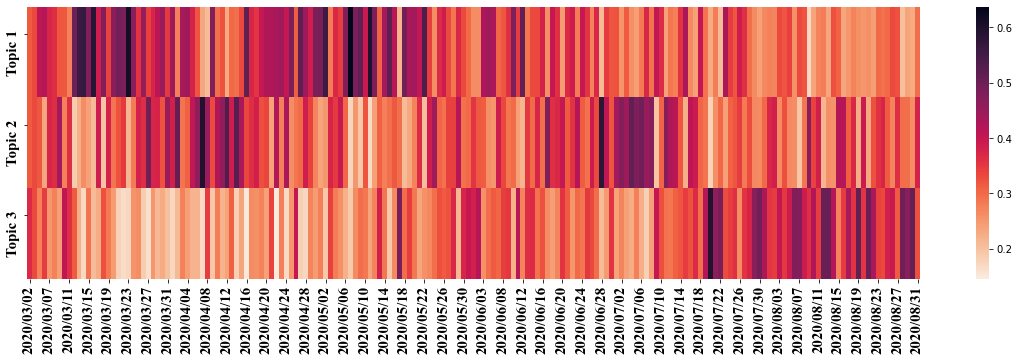

In [72]:
fig = drawTrend_heatmap(cbs_dtp_list1,0.3)
if save_plot :
       fig.savefig(r'./Plot/CBS_KDKA/topic_trending_heatmap1.jpg', bbox_inches = 'tight')

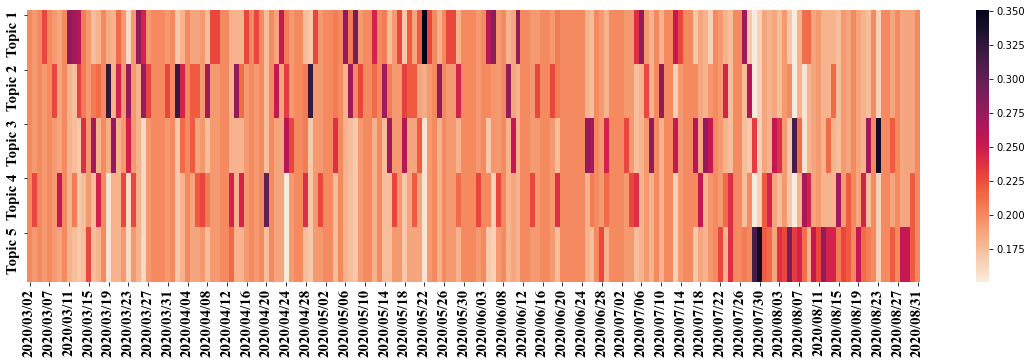

In [73]:
fig = drawTrend_heatmap(cbs_dtp_list2,0.1)
if save_plot :
       fig.savefig(r'./Plot/CBS_KDKA/topic_trending_heatmap2.jpg', bbox_inches = 'tight')

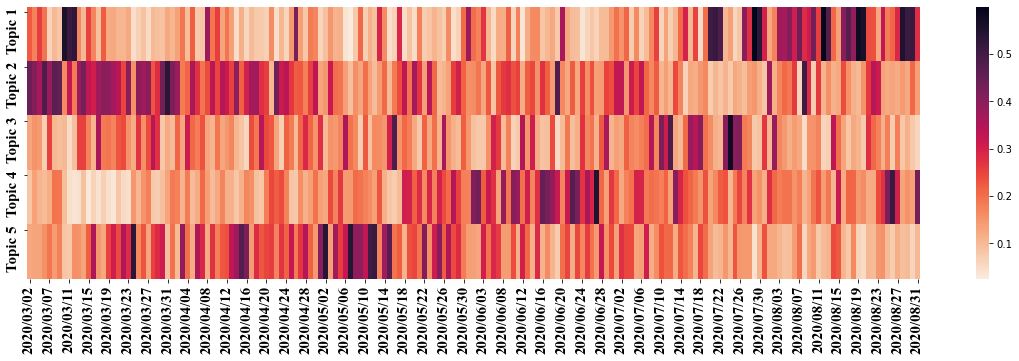

In [74]:
fig = drawTrend_heatmap(cbs_dtp_list3,0.1)
if save_plot :
       fig.savefig(r'./Plot/CBS_KDKA/topic_trending_heatmap3.jpg', bbox_inches = 'tight')

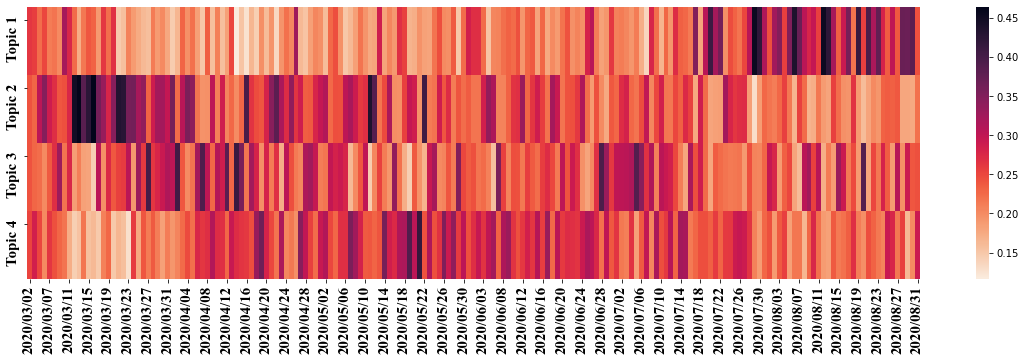

In [75]:
fig = drawTrend_heatmap(cbs_dtp_list4,0.2)
if save_plot :
       fig.savefig(r'./Plot/CBS_KDKA/topic_trending_heatmap4.jpg', bbox_inches = 'tight')

In [147]:
#  Visualization 2
def drawTrend(cbs_dtp_list,title_y_coordinate=0.55): 
    topic_percent_data = cbs_dtp_list.loc[:,'Topic 1':]
    maxVal = topic_percent_data.max().max()
    minVal = topic_percent_data.min().min()
    n = len(cbs_dtp_list.index)
    daily_index = np.arange(n)
    topicNum = len(topic_percent_data.columns)
    topics = ['Topic %d'%(x+1) for x in range(topicNum)]
    
    Colors_RGB = [ [155, 34, 38],
                 [202, 103, 2],
                 [10, 147, 150],
                 [0, 95, 115],
                 [0, 18, 25] ]

    Colors = list(np.array(Colors_RGB)/255)

    fig = plt.figure(figsize = (20,10))
    fig.text(0.09, title_y_coordinate, 'Percentage Topic Composition %', va='center', rotation='vertical', 
         fontproperties = 'Times New Roman',fontsize = 20,fontweight="bold")
    
    grid = plt.GridSpec(36, 10, wspace=1.5, hspace=1.5);
    
    startindex = list(np.arange(topicNum)*6)
    subplotindex = [0,4,6,10,12,16,18,22,24,28,30]
    
    
    # Subplots
    for i in startindex :
        plt.subplot(grid[i:i+4,:])
        plt.plot ( daily_index, 25*np.ones_like(daily_index) , linewidth = 2 ,
                   linestyle = '-.' , color = (141/255, 153/255, 174/255)  ) 
        h = plt.plot ( daily_index, topic_percent_data[topics[startindex.index(i)]]*100 , linewidth = 2 ,
                   linestyle = '-' , color = tuple(Colors[startindex.index(i)]) )

        plt.xticks([]) 
        plt.xlim(0,len(daily_index)) 
        plt.legend( handles = h, labels = [topics[startindex.index(i)]] , loc = 'upper right' , 
                   prop = {'weight':'bold','family':'Times New Roman'})

        plt.subplot(grid[i+4:i+6,:])
        ax = sns.heatmap(pd.DataFrame(topic_percent_data[topics[startindex.index(i)]]).T, 
                    center = (maxVal+minVal)/2, cbar = False, 
                    xticklabels = False, yticklabels = False)
        plt.xlabel('',fontproperties = 'Times New Roman',fontsize = 25,fontweight="bold")
       
        if startindex.index(i) == topicNum-1:
            ax.set_xticks(list(daily_index[0::3]))
            ax.set_xticklabels(list(topic_percent_data.index[list(daily_index[0::3])]))
            plt.xticks(fontproperties = 'Times New Roman', size = 15, fontweight="bold",rotation=90)
        
        
        
    return fig


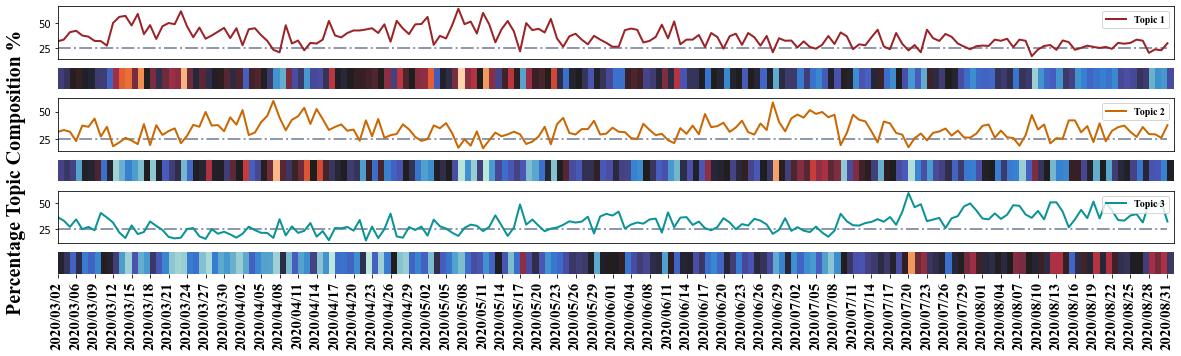

In [148]:
fig1 =  drawTrend(cbs_dtp_list1, title_y_coordinate = 0.65)

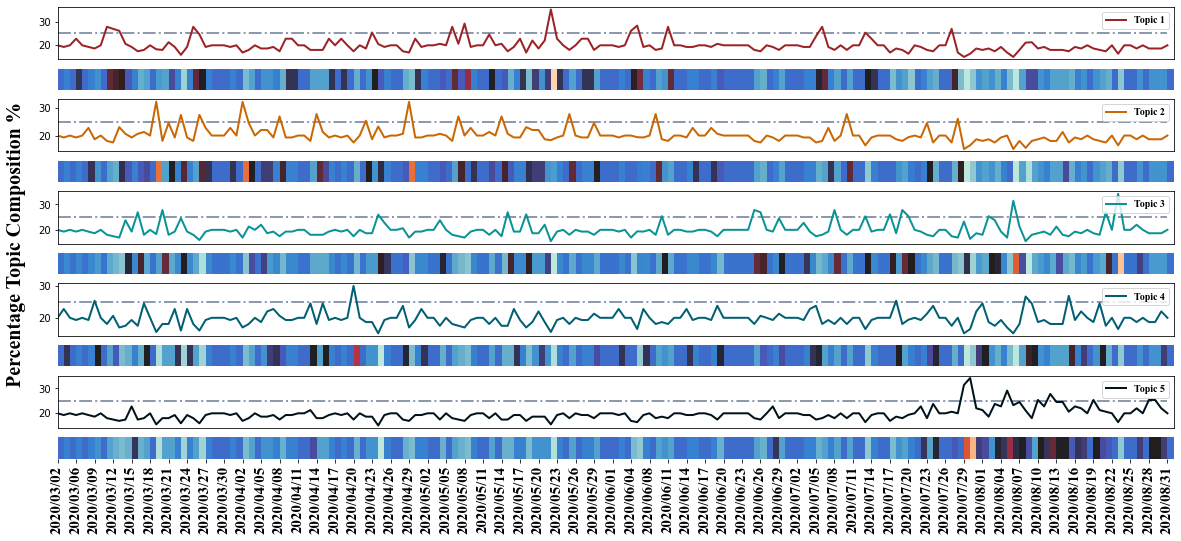

In [149]:
fig2 =  drawTrend(cbs_dtp_list2, title_y_coordinate = 0.55)

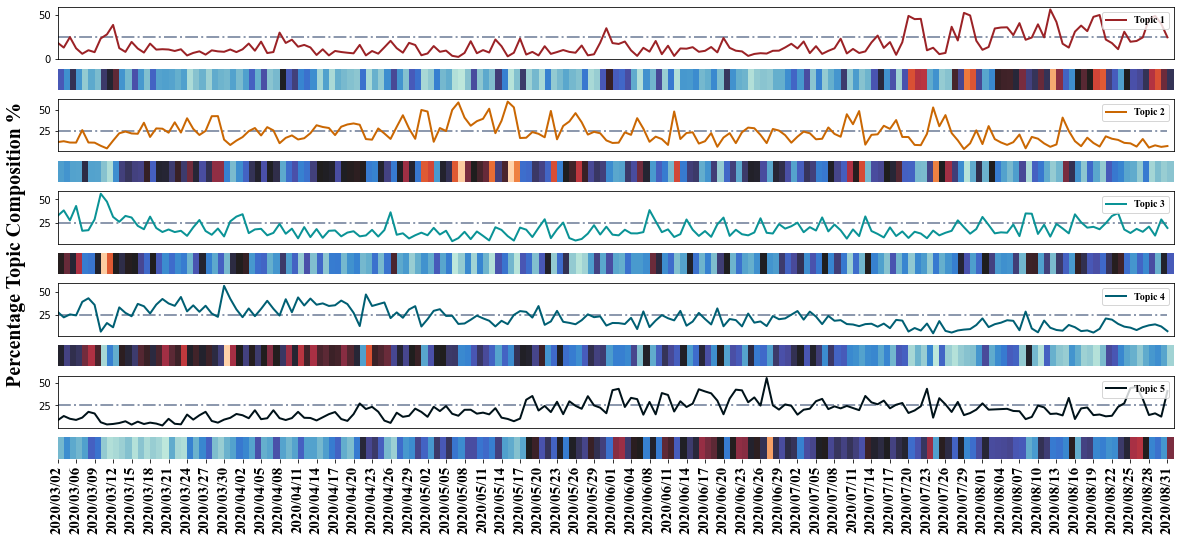

In [150]:
fig3 =  drawTrend(cbs_dtp_list3, title_y_coordinate = 0.55)

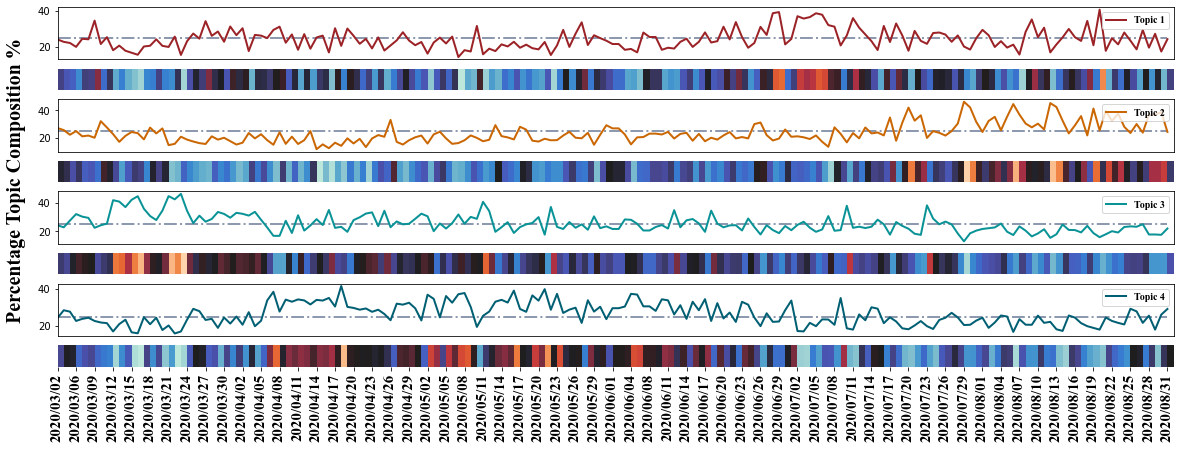

In [167]:
fig4 =  drawTrend(cbs_dtp_list4, title_y_coordinate = 0.64)

In [168]:
if save_plot :
    fig1.savefig(r'./Plot/CBS_KDKA/topic_trending1.jpg', bbox_inches = 'tight')
    fig2.savefig(r'./Plot/CBS_KDKA/topic_trending2.jpg', bbox_inches = 'tight')
    fig3.savefig(r'./Plot/CBS_KDKA/topic_trending3.jpg', bbox_inches = 'tight')
    fig4.savefig(r'./Plot/CBS_KDKA/topic_trending4.jpg', bbox_inches = 'tight')